In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, r2_score,
roc_auc_score, roc_curve, mean_squared_error, mean_absolute_error, root_mean_squared_error)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier 
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.under_sampling import RandomUnderSampler
import collections
from sklearn.metrics import f1_score
import pickle

C:\Anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df_train= pd.read_csv('cleaned_train.csv')
df_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,0,0.0,1,0,0,0,0,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0,0.0,1,0,0,0,0,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,1,0.0,1,0,1,0,0,0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0,0.0,1,0,0,0,0,0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,1,0.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305716,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,1,0.0,1,1,0,0,0,0,0
305717,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,1,0.0,0,1,0,0,0,1,0
305718,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0,0.0,1,0,0,0,0,0,0
305719,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,NaN,1,0.0,1,1,0,0,0,0,0


In [66]:
df_train.shape

(305721, 106)

In [17]:
df_train = pd.read_csv("final_clean_train.csv")
df_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PAYMENT_COMPLETION_RATE,DELAY_TO_CREDIT_RATIO,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.999995,-0.816842,1.0,0,0.0,1,0,0,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.999999,-0.650909,0.0,0,0.0,1,0,0,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.999953,-1.533333,NaN,1,0.0,1,0,1,0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.999999,-0.952869,0.0,0,0.0,1,0,0,0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.964284,-0.167832,NaN,1,0.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154785,279418,0,Cash loans,F,N,N,0,69750.0,618840.0,17145.0,...,0.999974,-1.714286,0.0,0,0.0,1,1,0,0,0
154786,279419,0,Cash loans,M,Y,Y,1,112500.0,157500.0,17091.0,...,0.999995,-1.171946,0.0,0,0.0,1,0,1,0,0
154787,279420,0,Cash loans,M,N,Y,0,180000.0,128092.5,10039.5,...,1.065676,-0.426639,0.0,0,0.0,1,1,0,0,0
154788,279421,0,Revolving loans,F,Y,Y,0,225000.0,157500.0,7875.0,...,0.000000,0.000000,0.0,0,0.0,1,1,1,0,0


In [4]:
pd.set_option('display.max_columns', None)
list(df_train.columns)

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',

In [18]:
df_test = pd.read_csv("final_clean_test.csv")
df_test

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
0,100001,0.0,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,NaN,1,0.000000,1,0,0,0,0,1,0
1,100005,0.0,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,NaN,1,0.000000,1,1,0,0,0,0,0
2,100013,0.0,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,NaN,1,0.137869,1,0,1,0,0,0,1
3,100028,0.0,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,NaN,1,0.035934,1,0,0,0,0,0,0
4,100038,0.0,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,NaN,1,0.000000,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,0.0,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,...,0.0,0,0.000000,1,0,0,0,0,1,0
48740,456222,0.0,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,...,0.0,0,0.000000,1,1,0,0,0,0,0
48741,456223,0.0,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,...,NaN,1,0.000000,1,0,1,0,0,1,0
48742,456224,0.0,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,...,NaN,1,0.000000,1,0,0,0,0,0,0


In [19]:
df_train = df_train.drop('SK_ID_PREV_NUNIQUE', axis=1)
df_test = df_test.drop('SK_ID_PREV_NUNIQUE', axis=1)

In [3]:
df_test = pd.read_csv("cleaned_test.csv")
df_test

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING,PRED
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,Unaccompanied,...,1,0.000000,1,0,0,0,0,0,0,0.255539
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,Unaccompanied,...,1,0.000000,1,1,0,0,0,0,0,0.642306
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,0,...,1,0.137869,1,0,1,0,0,0,0,0.157567
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,Unaccompanied,...,1,0.035934,1,0,0,0,0,0,0,0.309478
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,Unaccompanied,...,1,0.000000,1,0,0,0,0,0,0,0.635119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48419,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,Unaccompanied,...,0,0.000000,1,0,0,0,0,0,0,0.331809
48420,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,Unaccompanied,...,0,0.000000,1,1,0,0,0,0,0,0.394263
48421,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,Unaccompanied,...,1,0.000000,1,0,1,0,0,0,0,0.214243
48422,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,Family,...,1,0.000000,1,0,0,0,0,0,0,0.425368


In [14]:
df_train['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [4]:
{col: df_train[col].value_counts() for col in df_train.select_dtypes(include='object').columns}

{'NAME_CONTRACT_TYPE': NAME_CONTRACT_TYPE
 Cash loans         278232
 Revolving loans     29279
 Name: count, dtype: int64,
 'CODE_GENDER': CODE_GENDER
 F      202448
 M      105059
 XNA         4
 Name: count, dtype: int64,
 'FLAG_OWN_CAR': FLAG_OWN_CAR
 N    202924
 Y    104587
 Name: count, dtype: int64,
 'FLAG_OWN_REALTY': FLAG_OWN_REALTY
 Y    213312
 N     94199
 Name: count, dtype: int64,
 'NAME_TYPE_SUITE': NAME_TYPE_SUITE
 Unaccompanied      248526
 Family              40149
 Spouse, partner     11370
 Children             3267
 Other_B              1770
 Unknown              1292
 Other_A               866
 Group of people       271
 Name: count, dtype: int64,
 'NAME_INCOME_TYPE': NAME_INCOME_TYPE
 Working                 158774
 Commercial associate     71617
 Pensioner                55362
 State servant            21703
 Unemployed                  22
 Student                     18
 Businessman                 10
 Maternity leave              5
 Name: count, dtype: int64,

In [8]:
df_train['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [20]:
def preprocess_data(df_train):
    import numpy as np
    import pandas as pd
    
    # ----------------------------
    # 1. REMOVE INVALID ROWS
    # ----------------------------
    df_train = df_train[df_train['CODE_GENDER'] != 'XNA']
    df_train = df_train[df_train['NAME_FAMILY_STATUS'] != 'Unknown']
    
    # ----------------------------
    # 2. FIX XNA (ORG TYPE)
    # ----------------------------
    mode_org = df_train.loc[df_train['ORGANIZATION_TYPE'] != 'XNA', 'ORGANIZATION_TYPE'].mode()[0]
    df_train['ORGANIZATION_TYPE'] = df_train['ORGANIZATION_TYPE'].replace('XNA', mode_org)
    
    # ----------------------------
    # 3. HANDLE UNKNOWN → MISSING
    # ----------------------------
    df_train['OCCUPATION_TYPE'] = df_train['OCCUPATION_TYPE'].replace('Unknown', np.nan)
    df_train['NAME_TYPE_SUITE'] = df_train['NAME_TYPE_SUITE'].replace('Unknown', np.nan)
    
    # Missing flags (important)
    df_train['OCCUPATION_TYPE_MISSING'] = df_train['OCCUPATION_TYPE'].isna().astype(int)
    df_train['NAME_TYPE_SUITE_MISSING'] = df_train['NAME_TYPE_SUITE'].isna().astype(int)
    
    # ----------------------------
    # 4. GROUP RARE CATEGORIES
    # ----------------------------
    def group_rare(series, threshold=1000):
        counts = series.value_counts()
        rare = counts[counts < threshold].index
        return series.replace(rare, 'Other')
    
    df_train['ORGANIZATION_TYPE'] = group_rare(df_train['ORGANIZATION_TYPE'])
    df_train['OCCUPATION_TYPE'] = group_rare(df_train['OCCUPATION_TYPE'])

    return df_train

In [21]:
df_train = preprocess_data(df_train)

In [22]:
df_train['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    62157
Self-employed             19182
Other                     18429
Medicine                   5652
Business Entity Type 2     5400
Government                 5201
School                     4511
Trade: type 7              3884
Kindergarten               3505
Construction               3256
Business Entity Type 1     3011
Transport: type 4          2713
Trade: type 3              1718
Industry: type 3           1689
Security                   1667
Industry: type 9           1657
Housing                    1468
Industry: type 11          1397
Military                   1348
Bank                       1299
Agriculture                1225
Police                     1154
Postal                     1121
Transport: type 2          1119
Security Ministries        1023
Name: count, dtype: int64

In [23]:
def preprocess_data(df_test):
    import numpy as np
    import pandas as pd
    
    # ----------------------------
    # 1. REMOVE INVALID ROWS
    # ----------------------------
    df_test = df_test[df_test['CODE_GENDER'] != 'XNA']
    df_test = df_test[df_test['NAME_FAMILY_STATUS'] != 'Unknown']
    
    # ----------------------------
    # 2. FIX XNA (ORG TYPE)
    # ----------------------------
    mode_org = df_test.loc[df_test['ORGANIZATION_TYPE'] != 'XNA', 'ORGANIZATION_TYPE'].mode()[0]
    df_test['ORGANIZATION_TYPE'] = df_test['ORGANIZATION_TYPE'].replace('XNA', mode_org)
    
    # ----------------------------
    # 3. HANDLE UNKNOWN → MISSING
    # ----------------------------
    df_test['OCCUPATION_TYPE'] = df_test['OCCUPATION_TYPE'].replace('Unknown', np.nan)
    df_test['NAME_TYPE_SUITE'] = df_test['NAME_TYPE_SUITE'].replace('Unknown', np.nan)
    
    # Missing flags (important)
    df_test['OCCUPATION_TYPE_MISSING'] = df_test['OCCUPATION_TYPE'].isna().astype(int)
    df_test['NAME_TYPE_SUITE_MISSING'] = df_test['NAME_TYPE_SUITE'].isna().astype(int)
    
    # ----------------------------
    # 4. GROUP RARE CATEGORIES
    # ----------------------------
    def group_rare(series, threshold=1000):
        counts = series.value_counts()
        rare = counts[counts < threshold].index
        return series.replace(rare, 'Other')
    
    df_test['ORGANIZATION_TYPE'] = group_rare(df_test['ORGANIZATION_TYPE'])
    df_test['OCCUPATION_TYPE'] = group_rare(df_test['OCCUPATION_TYPE'])

    return df_test

In [24]:
df_test = preprocess_data(df_test)

In [6]:
df_train['CODE_GENDER'].value_counts()

CODE_GENDER
F    201241
M    104480
Name: count, dtype: int64

In [16]:
df_train.to_csv("final_clean_train.csv", index=False)
df_test.to_csv("final_clean_test.csv", index=False)

In [17]:
df_train.shape

(305721, 120)

In [18]:
df_test.shape

(48744, 123)

In [30]:
df_train['TARGET'].value_counts()

TARGET
0    282680
1     24825
Name: count, dtype: int64

In [8]:
df_train['PAYMENT_COMPLETION_RATE'].describe()

count    3.075110e+05
mean     9.205778e+00
std      4.479401e+03
min      0.000000e+00
25%      9.449705e-01
50%      9.999856e-01
75%      9.999971e-01
max      2.483614e+06
Name: PAYMENT_COMPLETION_RATE, dtype: float64

In [25]:
df_train[df_train['PAYMENT_COMPLETION_RATE'] > 6]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
126768,247019,0,Cash loans,M,Y,N,0,135000.0,970380.0,28503.0,...,NaN,1,0.0,1,0,0,0,0,0,0
128791,249387,0,Cash loans,M,Y,Y,0,112500.0,808650.0,26217.0,...,NaN,1,0.0,0,1,1,0,0,1,0


In [26]:
df_test[df_test['PAYMENT_COMPLETION_RATE'] > 6]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING


In [27]:
df_train = df_train[df_train['PAYMENT_COMPLETION_RATE'] <= 6]

In [28]:
df_test = df_test[df_test['PAYMENT_COMPLETION_RATE'] <= 6]

In [29]:
df_train[df_train['UTIL_BALANCE_RATIO'] > 5]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
1381,101622,0,Cash loans,M,Y,Y,1,225000.0,543037.5,39645.0,...,NaN,1,10314.000,1,0,1,0,0,0,0
10736,112503,1,Cash loans,F,N,N,0,76500.0,545040.0,26509.5,...,NaN,1,2351.565,1,0,0,0,0,0,0
10863,112643,0,Revolving loans,F,N,Y,1,135000.0,202500.0,10125.0,...,NaN,1,43000.200,1,0,0,0,0,0,0
17723,120661,0,Cash loans,F,N,Y,0,112500.0,283419.0,22522.5,...,NaN,1,1858.500,1,0,0,0,0,0,0
19025,122189,0,Cash loans,F,Y,Y,0,247500.0,1072809.0,31495.5,...,0.0000,0,3141.000,1,0,1,0,0,0,0
20236,123610,0,Cash loans,M,N,Y,0,270000.0,668484.0,26032.5,...,NaN,1,1593.000,1,1,0,0,0,0,0
21600,125160,1,Cash loans,F,N,Y,0,192600.0,288873.0,13594.5,...,0.0000,0,1062.000,1,1,0,0,0,0,0
21913,125529,0,Cash loans,F,N,Y,1,90000.0,675000.0,21906.0,...,NaN,1,265.500,1,0,0,0,0,1,0
23028,126798,0,Cash loans,M,Y,Y,0,157500.0,225000.0,8613.0,...,0.0000,0,2285958.915,1,0,1,0,0,0,0
24903,128963,0,Cash loans,F,N,N,1,112500.0,344043.0,23274.0,...,0.2500,0,351.000,1,0,0,0,0,0,0


In [30]:
df_train.shape

(154784, 123)

In [31]:
df_test[df_test['UTIL_BALANCE_RATIO'] > 5]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
3250,122845,0.0,Cash loans,F,N,Y,0,135000.0,296280.0,18256.5,...,0.000000,0,3141.000,0,0,0,0,0,1,0
3827,127226,0.0,Cash loans,F,N,Y,0,135000.0,99504.0,10575.0,...,0.000000,0,9063.000,1,0,0,0,0,0,0
4917,135530,0.0,Cash loans,F,N,Y,0,157500.0,450000.0,32877.0,...,NaN,1,531.000,1,0,0,0,0,0,0
6317,146221,0.0,Cash loans,F,N,Y,1,135000.0,382050.0,25659.0,...,NaN,1,9963.000,1,0,0,0,0,0,0
8558,162504,0.0,Cash loans,F,Y,Y,0,405000.0,509400.0,40374.0,...,NaN,1,10993.500,1,1,1,0,0,0,0
12817,193289,0.0,Cash loans,F,N,Y,0,135000.0,509400.0,32683.5,...,NaN,1,1327.500,0,0,0,0,0,1,0
14144,202073,0.0,Cash loans,M,N,Y,1,382500.0,382050.0,30181.5,...,0.000000,0,1345.500,1,0,0,0,0,0,0
15003,208110,0.0,Cash loans,F,Y,Y,1,180000.0,224149.5,23665.5,...,NaN,1,14134.500,0,0,1,0,0,1,0
15018,208178,0.0,Cash loans,F,N,Y,0,144000.0,225000.0,23184.0,...,0.000000,0,3141.000,1,0,0,0,0,1,0
17449,226677,0.0,Cash loans,F,Y,Y,0,225000.0,690763.5,55512.0,...,NaN,1,2124.000,1,0,1,0,0,1,0


In [32]:
df_train = df_train[df_train['UTIL_BALANCE_RATIO'] <= 5]

In [33]:
df_test = df_test[df_test['UTIL_BALANCE_RATIO'] <= 5]

In [163]:
df_test.shape

(48717, 106)

In [34]:
df_train[df_train['UTILIZATION_MEAN'] > 5]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
223,100260,0,Cash loans,M,N,Y,0,180000.0,180000.0,20488.5,...,0.0,0,0.074471,1,0,0,0,0,0,0
752,100865,0,Cash loans,F,Y,Y,2,112500.0,573628.5,24435.0,...,NaN,1,0.313841,1,0,1,0,0,0,0
1047,101216,0,Cash loans,F,Y,Y,0,135000.0,518562.0,22099.5,...,0.0,0,0.261620,1,0,1,0,0,0,0
1061,101232,0,Cash loans,F,N,Y,1,189000.0,1288350.0,37800.0,...,NaN,1,0.266126,1,1,0,0,0,0,0
2045,102396,0,Cash loans,F,N,Y,0,225000.0,785398.5,33403.5,...,0.0,0,0.285720,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148909,272646,0,Cash loans,F,N,Y,0,337500.0,654498.0,26086.5,...,NaN,1,0.252016,0,0,0,0,0,1,0
149086,272850,0,Cash loans,M,Y,Y,1,81000.0,276277.5,19777.5,...,1.0,0,0.287191,1,1,1,0,0,1,0
149651,273500,0,Cash loans,F,Y,Y,0,90000.0,254700.0,17149.5,...,NaN,1,0.120821,1,0,1,0,0,0,0
150823,274831,0,Cash loans,F,Y,Y,0,225000.0,760500.0,32350.5,...,NaN,1,0.009248,1,0,1,0,0,0,0


In [165]:
df_test[df_test['UTILIZATION_MEAN'] > 5]

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING,PRED
1348,109469,Cash loans,F,N,N,0,211500.0,454500.0,20020.5,Unaccompanied,...,1,0.434861,0,0,0,0,0,0,0,0.261816
1927,113587,Cash loans,F,N,Y,1,135000.0,301896.0,23490.0,0,...,0,0.568899,1,0,0,0,0,0,0,0.737829
2420,116949,Cash loans,F,Y,N,0,225000.0,590485.5,43096.5,Unaccompanied,...,0,0.774994,1,1,0,0,0,0,0,0.659777
3202,122415,Cash loans,F,N,N,0,112500.0,135000.0,10444.5,Unaccompanied,...,1,0.127671,1,0,0,0,0,0,0,0.493549
3307,123207,Cash loans,F,N,N,0,112500.0,351000.0,18049.5,Family,...,1,0.191502,1,0,0,0,0,0,0,0.202772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44454,424839,Cash loans,F,N,Y,1,72000.0,225000.0,23769.0,"Spouse, partner",...,0,0.314078,1,0,0,0,0,0,0,0.137073
45125,430467,Cash loans,F,Y,Y,0,135000.0,450000.0,43839.0,Unaccompanied,...,1,0.212095,1,0,1,0,0,0,0,0.222593
46924,442846,Cash loans,F,Y,Y,0,112500.0,337500.0,35568.0,Unaccompanied,...,0,0.140250,1,1,1,0,0,0,0,0.412467
47859,449773,Cash loans,F,Y,Y,0,351000.0,509922.0,39591.0,Unaccompanied,...,0,0.030119,1,0,1,0,0,0,0,0.336887


In [35]:
df_train = df_train[df_train['UTILIZATION_MEAN'] < 5]

In [36]:
df_test = df_test[df_test['UTILIZATION_MEAN'] < 5]

In [37]:
df_train[df_train['UTILIZATION_MAX'] > 5]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
1636,101918,0,Cash loans,F,N,N,0,117000.0,258709.5,25330.5,...,NaN,1,0.224642,1,0,0,0,0,0,0
2185,102565,0,Cash loans,F,N,Y,1,225000.0,675000.0,52366.5,...,0.0,0,0.000009,1,0,0,0,0,0,0
2977,103477,1,Cash loans,F,N,Y,0,58500.0,157050.0,8649.0,...,0.2,0,0.460779,1,0,0,0,0,0,0
3620,104226,0,Cash loans,F,N,Y,0,40500.0,251280.0,12217.5,...,0.0,0,0.347049,0,1,0,0,0,1,0
5431,106357,0,Cash loans,M,Y,Y,0,360000.0,945000.0,39127.5,...,NaN,1,0.185363,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147415,270923,1,Cash loans,M,Y,Y,0,247500.0,1569051.0,54670.5,...,NaN,1,0.748459,1,0,1,0,0,0,0
148458,272133,0,Cash loans,F,N,Y,2,67500.0,180000.0,12028.5,...,NaN,1,0.105924,1,0,0,0,0,0,0
149741,273601,0,Cash loans,M,N,N,1,157500.0,254700.0,16582.5,...,NaN,1,0.357569,1,1,0,0,0,0,0
150496,274463,0,Cash loans,F,N,Y,0,202500.0,986782.5,53662.5,...,NaN,1,0.399756,1,0,0,0,0,1,0


In [38]:
df_test[df_test['UTILIZATION_MAX'] > 5]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
2683,118823,0.0,Cash loans,M,Y,Y,2,306000.0,539100.0,29376.0,...,0.00,0,0.672517,1,0,1,0,0,0,0
5854,142803,0.0,Cash loans,F,N,Y,0,135000.0,286704.0,17667.0,...,NaN,1,0.569515,1,0,0,0,0,0,0
10166,173874,0.0,Cash loans,F,N,N,0,202500.0,532494.0,29731.5,...,NaN,1,0.127312,0,0,0,0,0,1,0
10544,176579,0.0,Cash loans,M,Y,Y,1,450000.0,786505.5,40288.5,...,0.00,0,0.133556,1,0,1,0,0,0,0
15484,211696,0.0,Cash loans,M,Y,Y,0,157500.0,260640.0,27499.5,...,NaN,1,0.308480,1,1,1,0,0,0,0
15510,211901,0.0,Cash loans,F,N,Y,0,126000.0,228915.0,16785.0,...,0.00,0,0.043001,1,0,0,0,0,0,0
15749,213534,0.0,Cash loans,F,N,N,0,157500.0,1125000.0,50314.5,...,NaN,1,0.274764,1,0,0,0,0,0,0
15855,214337,0.0,Cash loans,M,N,Y,0,180000.0,93829.5,9981.0,...,NaN,1,0.108356,1,0,0,0,0,0,0
15883,214484,0.0,Cash loans,F,N,Y,0,130500.0,532494.0,30699.0,...,NaN,1,0.493085,0,0,0,0,0,1,0
17729,228488,0.0,Cash loans,M,N,Y,1,270000.0,573408.0,29407.5,...,0.50,0,0.615225,1,0,0,0,0,0,0


In [39]:
df_train = df_train[df_train['UTILIZATION_MAX'] < 5]

In [40]:
df_test = df_test[df_test['UTILIZATION_MAX'] < 5]

In [41]:
df_train[df_train['DRAWING_RATIO_MEAN'] > 20]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
284,100327,0,Cash loans,M,Y,Y,0,180000.0,407727.0,32341.5,...,NaN,1,0.603927,1,0,1,0,0,1,0
1010,101168,0,Cash loans,F,N,Y,0,130500.0,548770.5,21892.5,...,NaN,1,0.166106,0,0,0,0,0,1,0
1032,101196,0,Cash loans,M,N,Y,0,225000.0,549000.0,15228.0,...,0.0,0,0.000000,1,0,0,0,0,0,0
1474,101734,0,Cash loans,F,N,Y,0,180000.0,344043.0,18661.5,...,NaN,1,0.000000,0,1,0,0,0,1,0
1589,101860,0,Cash loans,F,N,Y,0,67500.0,140746.5,11020.5,...,NaN,1,0.000000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153934,278404,0,Cash loans,M,Y,N,0,405000.0,781920.0,39852.0,...,NaN,1,0.495182,1,0,0,0,0,1,0
153988,278468,0,Cash loans,F,N,Y,0,202500.0,1007761.5,40095.0,...,NaN,1,0.000000,1,0,0,0,0,0,0
154328,278866,0,Cash loans,M,Y,Y,0,144000.0,343683.0,18121.5,...,0.0,0,0.000000,1,1,1,0,0,0,0
154700,279317,0,Cash loans,M,N,Y,1,270000.0,165915.0,13239.0,...,NaN,1,0.000000,1,1,0,0,0,1,0


In [42]:
df_test[df_test['DRAWING_RATIO_MEAN'] > 20]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
153,101136,0.0,Cash loans,F,Y,Y,0,94500.0,104256.0,11358.0,...,0.0,0,0.000000,1,0,1,0,0,1,0
246,101669,0.0,Cash loans,F,N,Y,0,67500.0,98109.0,7267.5,...,NaN,1,0.000000,0,1,0,0,0,1,0
903,106256,0.0,Cash loans,F,N,Y,0,157500.0,301464.0,19413.0,...,0.0,0,0.000000,0,0,0,0,0,1,0
1262,108901,0.0,Cash loans,M,N,Y,0,292500.0,1125000.0,47794.5,...,NaN,1,0.500833,1,0,0,0,0,0,0
1623,111544,0.0,Cash loans,F,N,Y,0,54000.0,104256.0,8487.0,...,NaN,1,0.000000,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47456,446850,0.0,Cash loans,M,Y,N,0,99000.0,398250.0,17541.0,...,NaN,1,0.203937,1,0,0,0,0,0,0
47470,446945,0.0,Cash loans,F,N,Y,0,180000.0,156384.0,15597.0,...,NaN,1,0.373138,1,0,0,0,0,0,0
47611,447972,0.0,Cash loans,M,N,Y,0,180000.0,450000.0,35554.5,...,NaN,1,0.000000,1,1,0,0,0,0,0
47648,448241,0.0,Cash loans,F,N,Y,0,157500.0,218016.0,17352.0,...,0.0,0,0.000000,1,1,0,0,0,1,0


In [43]:
df_test = df_test[df_test['DRAWING_RATIO_MEAN'] <= 20]

In [44]:
df_train = df_train[df_train['DRAWING_RATIO_MEAN'] <= 20]

In [45]:
df_train[df_train['PAYMENT_RATIO_MEAN'] > 100]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0.0,0,0.331825,0,1,0,0,1,1,0
41,100048,0,Cash loans,F,N,Y,0,202500.0,604152.0,29196.0,...,0.0,0,0.265825,1,0,0,0,0,0,0
70,100082,0,Cash loans,M,N,N,2,180000.0,450000.0,21109.5,...,NaN,1,0.144965,1,0,0,0,0,0,0
74,100086,0,Cash loans,F,N,Y,1,135000.0,675000.0,21775.5,...,NaN,1,0.409671,1,0,0,0,0,0,0
85,100100,0,Cash loans,M,Y,Y,2,202500.0,796396.5,38443.5,...,NaN,1,0.489879,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154743,279369,0,Cash loans,M,Y,N,0,225000.0,1129500.0,31189.5,...,NaN,1,0.108928,1,0,0,0,0,1,0
154752,279380,0,Cash loans,F,N,N,0,148500.0,1107612.0,47056.5,...,0.0,0,0.130589,1,0,0,0,0,0,0
154753,279381,0,Cash loans,F,N,N,0,67500.0,1080000.0,31576.5,...,0.0,0,0.609512,1,0,0,0,0,0,0
154778,279411,0,Cash loans,M,N,Y,0,90000.0,454500.0,21865.5,...,NaN,1,0.122726,1,0,0,0,0,0,0


In [46]:
df_train = df_train.drop(columns=['PAYMENT_RATIO_MEAN'])
df_test = df_test.drop(columns=['PAYMENT_RATIO_MEAN'])

In [47]:
df_train.shape

(153858, 122)

In [48]:
df_test.shape

(48400, 121)

In [59]:
df_train_copy = df_train.copy()

In [60]:
df_train_copy.shape

(305721, 122)

In [61]:
delay_cols = [
    'PAYMENT_DELAY_MEAN',
    'PAYMENT_DELAY_MAX',
    'SERIOUS_LATE_MEAN',
    'BB_LATE_MEAN',
    'BB_SEVERE_LATE_MEAN'
]

for col in delay_cols:
    if col in df_train_copy.columns:
        df_train_copy[col] = df_train_copy[col].clip(-100, 100)

In [43]:
delay_cols = [
    'PAYMENT_DELAY_MEAN',
    'PAYMENT_DELAY_MAX',
    'SERIOUS_LATE_MEAN',
    'BB_LATE_MEAN',
    'BB_SEVERE_LATE_MEAN'
]

for col in delay_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].clip(-100, 100)

In [62]:
df_train_copy.shape

(305721, 122)

In [44]:
df_test.shape

(48400, 123)

In [177]:
for col in ['AMT_PAYMENT_SUM','AMT_BALANCE_SUM','AMT_CREDIT_SUM_SUM','AMT_INSTALMENT_SUM']:
    if col in df_train.columns:
        df_train[col] = df_train[col].clip(lower=0)

In [178]:
for col in ['AMT_PAYMENT_SUM','AMT_BALANCE_SUM','AMT_CREDIT_SUM_SUM','AMT_INSTALMENT_SUM']:
    if col in df_test.columns:
        df_test[col] = df_test[col].clip(lower=0)

In [179]:
cols = [
    'CREDIT_GOODS_RATIO',
    'CREDIT_OVERDUE_RATIO',
    'APP_CREDIT_RATIO_MEAN',
    'ANNUITY_CREDIT_RATIO_MEAN',
    'ANNUITY_INCOME_RATIO',
    'TOTAL_DEBT_BURDEN'
]

for col in cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')

In [180]:
cols = [
    'CREDIT_GOODS_RATIO',
    'CREDIT_OVERDUE_RATIO',
    'APP_CREDIT_RATIO_MEAN',
    'ANNUITY_CREDIT_RATIO_MEAN',
    'ANNUITY_INCOME_RATIO',
    'TOTAL_DEBT_BURDEN'
]

for col in cols:
    df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

In [181]:
df_train[cols] = df_train[cols].fillna(0)

df_train['CREDIT_GOODS_RATIO'] = df_train['CREDIT_GOODS_RATIO'].clip(0, 4)
df_train['CREDIT_OVERDUE_RATIO'] = df_train['CREDIT_OVERDUE_RATIO'].clip(0, 5)

df_train['APP_CREDIT_RATIO_MEAN'] = df_train['APP_CREDIT_RATIO_MEAN'].clip(0, 4)
df_train['ANNUITY_CREDIT_RATIO_MEAN'] = df_train['ANNUITY_CREDIT_RATIO_MEAN'].clip(0, 2)

df_train['ANNUITY_INCOME_RATIO'] = df_train['ANNUITY_INCOME_RATIO'].clip(0, 2)
df_train['TOTAL_DEBT_BURDEN'] = df_train['TOTAL_DEBT_BURDEN'].clip(0, 2)

In [182]:
df_test[cols] = df_test[cols].fillna(0)

df_test['CREDIT_GOODS_RATIO'] = df_test['CREDIT_GOODS_RATIO'].clip(0, 4)
df_test['CREDIT_OVERDUE_RATIO'] = df_test['CREDIT_OVERDUE_RATIO'].clip(0, 5)

df_test['APP_CREDIT_RATIO_MEAN'] = df_test['APP_CREDIT_RATIO_MEAN'].clip(0, 4)
df_test['ANNUITY_CREDIT_RATIO_MEAN'] = df_test['ANNUITY_CREDIT_RATIO_MEAN'].clip(0, 2)

df_test['ANNUITY_INCOME_RATIO'] = df_test['ANNUITY_INCOME_RATIO'].clip(0, 2)
df_test['TOTAL_DEBT_BURDEN'] = df_test['TOTAL_DEBT_BURDEN'].clip(0, 2)

In [67]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 305721 entries, 0 to 307504
Columns: 122 entries, SK_ID_CURR to NAME_TYPE_SUITE_MISSING
dtypes: float64(60), int64(50), str(12)
memory usage: 321.8 MB


In [112]:
print(df_train.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'TOTAL_DOCS', 'INCOME_CREDIT_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 'PHONE_CHANGE_YEAR

Text(0.5, 1.0, 'Class Distribution — Default vs Non-Default')

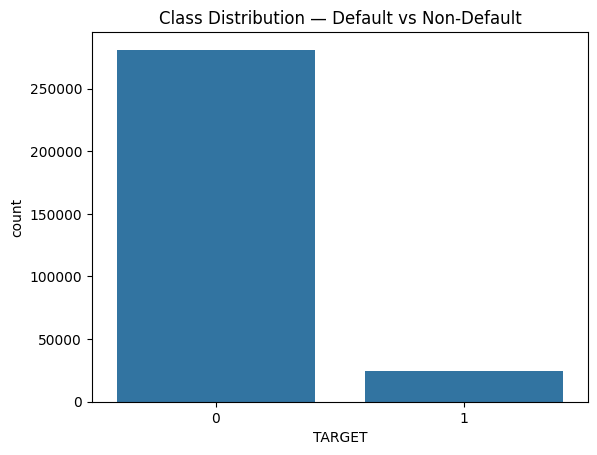

In [68]:
sns.countplot(x=df_train['TARGET'])
plt.title('Class Distribution — Default vs Non-Default')

df_train[df_train['CNT_INSTALMENT_SUM'] >= 500]

df_train[df_train['CNT_PAYMENT_SUM'] >= 500]

df_train[df_train['AMT_INCOME_TOTAL'] >= 1e7]

 df_train[df_train['INCOME_CREDIT_RATIO'] >= 20]

df_train[df_train['ANNUITY_INCOME_RATIO'] >= 1]

df_train[df_train['CREDIT_GOODS_RATIO'] >= 3]

# DROP truly bad
df_train = df_train[df_train['AMT_INCOME_TOTAL'] < 1e7]
df_train = df_train[df_train['INCOME_CREDIT_RATIO'] < 20]

In [91]:
df_train.shape

(307497, 123)

def get_upper_bound(col):
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    return upper

for col in ['CNT_INSTALMENT_SUM','CNT_PAYMENT_SUM',
            'ANNUITY_INCOME_RATIO','CREDIT_GOODS_RATIO']:
    print(col, get_upper_bound(col))

inst_bound = get_upper_bound('CNT_INSTALMENT_SUM')
pay_bound = get_upper_bound('CNT_PAYMENT_SUM')
ann_bound = get_upper_bound('ANNUITY_INCOME_RATIO')
cg_bound = get_upper_bound('CREDIT_GOODS_RATIO')

df_train = df_train[
    (df_train['CNT_INSTALMENT_SUM'] <= inst_bound) &
    (df_train['CNT_PAYMENT_SUM'] <= pay_bound) &
    (df_train['ANNUITY_INCOME_RATIO'] <= ann_bound) &
    (df_train['CREDIT_GOODS_RATIO'] <= cg_bound)
]

In [94]:
print("Shape after cleaning:", df_train.shape)

Shape after cleaning: (257614, 123)


In [41]:
df_train['TARGET'].value_counts()

TARGET
0.0    237363
1.0     20256
Name: count, dtype: int64

In [44]:
df_train['EMPLOYMENT_YEARS'].describe()

count    257619.000000
mean       -158.525360
std         372.673376
min       -1000.665753
25%           0.895890
50%           3.309589
75%           7.457534
max          49.073973
Name: EMPLOYMENT_YEARS, dtype: float64

In [69]:
df_train[df_train['EMPLOYMENT_YEARS'] < 0]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING


In [70]:
df_test[df_test['EMPLOYMENT_YEARS'] < 0]

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING,PRED


In [184]:
df_train[df_train['EMPLOYMENT_YEARS'] >= 0][
    ['EMPLOYMENT_YEARS']
].describe()

,EMPLOYMENT_YEARS
count,305721.000000
mean,6.736099
std,5.818672
min,0.000000
25%,2.553425
50%,6.073973
75%,7.673973
max,49.073973


In [187]:
df_train.loc[
    df_train['NAME_INCOME_TYPE'] == 'Unemployed',
    'EMPLOYMENT_YEARS'
] = 0

In [188]:
df_test.loc[
    df_test['NAME_INCOME_TYPE'] == 'Unemployed',
    'EMPLOYMENT_YEARS'
] = 0

In [189]:
df_train.shape

(305721, 106)

In [190]:
df_train.loc[df_train['EMPLOYMENT_YEARS'] < 0, 'EMPLOYMENT_YEARS'] = np.nan

pensioner_median = df_train.loc[
    (df_train['NAME_INCOME_TYPE'] == 'Pensioner') &
    (df_train['EMPLOYMENT_YEARS'].notna()),
    'EMPLOYMENT_YEARS'
].median()

df_train.loc[
    (df_train['NAME_INCOME_TYPE'] == 'Pensioner') &
    (df_train['EMPLOYMENT_YEARS'].isna()),
    'EMPLOYMENT_YEARS'
] = pensioner_median

In [191]:
df_train.shape

(305721, 106)

In [192]:
df_test.loc[df_test['EMPLOYMENT_YEARS'] < 0, 'EMPLOYMENT_YEARS'] = np.nan

pensioner_median = df_test.loc[
    (df_test['NAME_INCOME_TYPE'] == 'Pensioner') &
    (df_test['EMPLOYMENT_YEARS'].notna()),
    'EMPLOYMENT_YEARS'
].median()

df_test.loc[
    (df_test['NAME_INCOME_TYPE'] == 'Pensioner') &
    (df_test['EMPLOYMENT_YEARS'].isna()),
    'EMPLOYMENT_YEARS'
] = pensioner_median

In [193]:
df_test[df_test['EMPLOYMENT_YEARS'] >= 0][
    ['EMPLOYMENT_YEARS']
].describe()

,EMPLOYMENT_YEARS
count,39226.000000
mean,6.784431
std,6.325328
min,0.000000
25%,2.358904
50%,4.830137
75%,9.117808
max,47.843836


In [106]:
df_train[df_train['EMPLOYMENT_YEARS'] >= 0][
    ['EMPLOYMENT_YEARS']
].describe()

,EMPLOYMENT_YEARS
count,257614.000000
mean,6.776274
std,5.839920
min,0.000000
25%,2.410959
50%,5.643836
75%,8.934247
max,49.073973


In [195]:
df_test[df_test['EMPLOYMENT_YEARS']<0]

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING,PRED


In [107]:
df_train.shape

(257614, 123)

df_train = df_train[df_train['OBS_60_CNT_SOCIAL_CIRCLE'] <= 50]

df_train = df_train[df_train['AMT_BALANCE_SUM'] < 2e7]

df_train[df_train['AMT_CREDIT_SUM_DEBT_SUM'] > 1e8]

df_train = df_train[
    (df_train['AMT_BALANCE_SUM'] <= 2e7) &
    (df_train['AMT_CREDIT_SUM_DEBT_SUM'] <= 1e8)
]

In [115]:
df_train.shape

(257583, 123)

In [ ]:
#'PAYMENT_DELAY_MEAN',max <---drop them

In [73]:
cols = [
    'INCOME_CREDIT_RATIO','ANNUITY_INCOME_RATIO','CREDIT_GOODS_RATIO','DEBT_TO_INCOME',
    'CREDIT_OVERDUE_RATIO','TOTAL_DEBT_BURDEN','PAYMENT_COMPLETION_RATE',
    'UTIL_BALANCE_RATIO','UTILIZATION_MEAN',
    'DRAWING_RATIO_MEAN','APP_CREDIT_RATIO_MEAN',
    'ANNUITY_CREDIT_RATIO_MEAN'
]

# ensure numeric (in case some are object)
for col in cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')

# clip negatives to 0
df_train[cols] = df_train[cols].clip(lower=0)

In [71]:
cols = [
    'INCOME_CREDIT_RATIO','ANNUITY_INCOME_RATIO','CREDIT_GOODS_RATIO','DEBT_TO_INCOME',
    'CREDIT_OVERDUE_RATIO','TOTAL_DEBT_BURDEN','PAYMENT_COMPLETION_RATE',
    'UTIL_BALANCE_RATIO','UTILIZATION_MEAN',
    'DRAWING_RATIO_MEAN','APP_CREDIT_RATIO_MEAN',
    'ANNUITY_CREDIT_RATIO_MEAN'
]

# ensure numeric (in case some are object)
for col in cols:
    df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

# clip negatives to 0
df_test[cols] = df_test[cols].clip(lower=0)

In [72]:
df_train = df_train.drop(columns=['DEBT_RATIO_MEAN'])
df_train = df_train.drop(columns=['DELAY_TO_CREDIT_RATIO'])

df_test = df_test.drop(columns=['DEBT_RATIO_MEAN'])
df_test = df_test.drop(columns=['DELAY_TO_CREDIT_RATIO'])

KeyError: "['DELAY_TO_CREDIT_RATIO'] not found in axis"

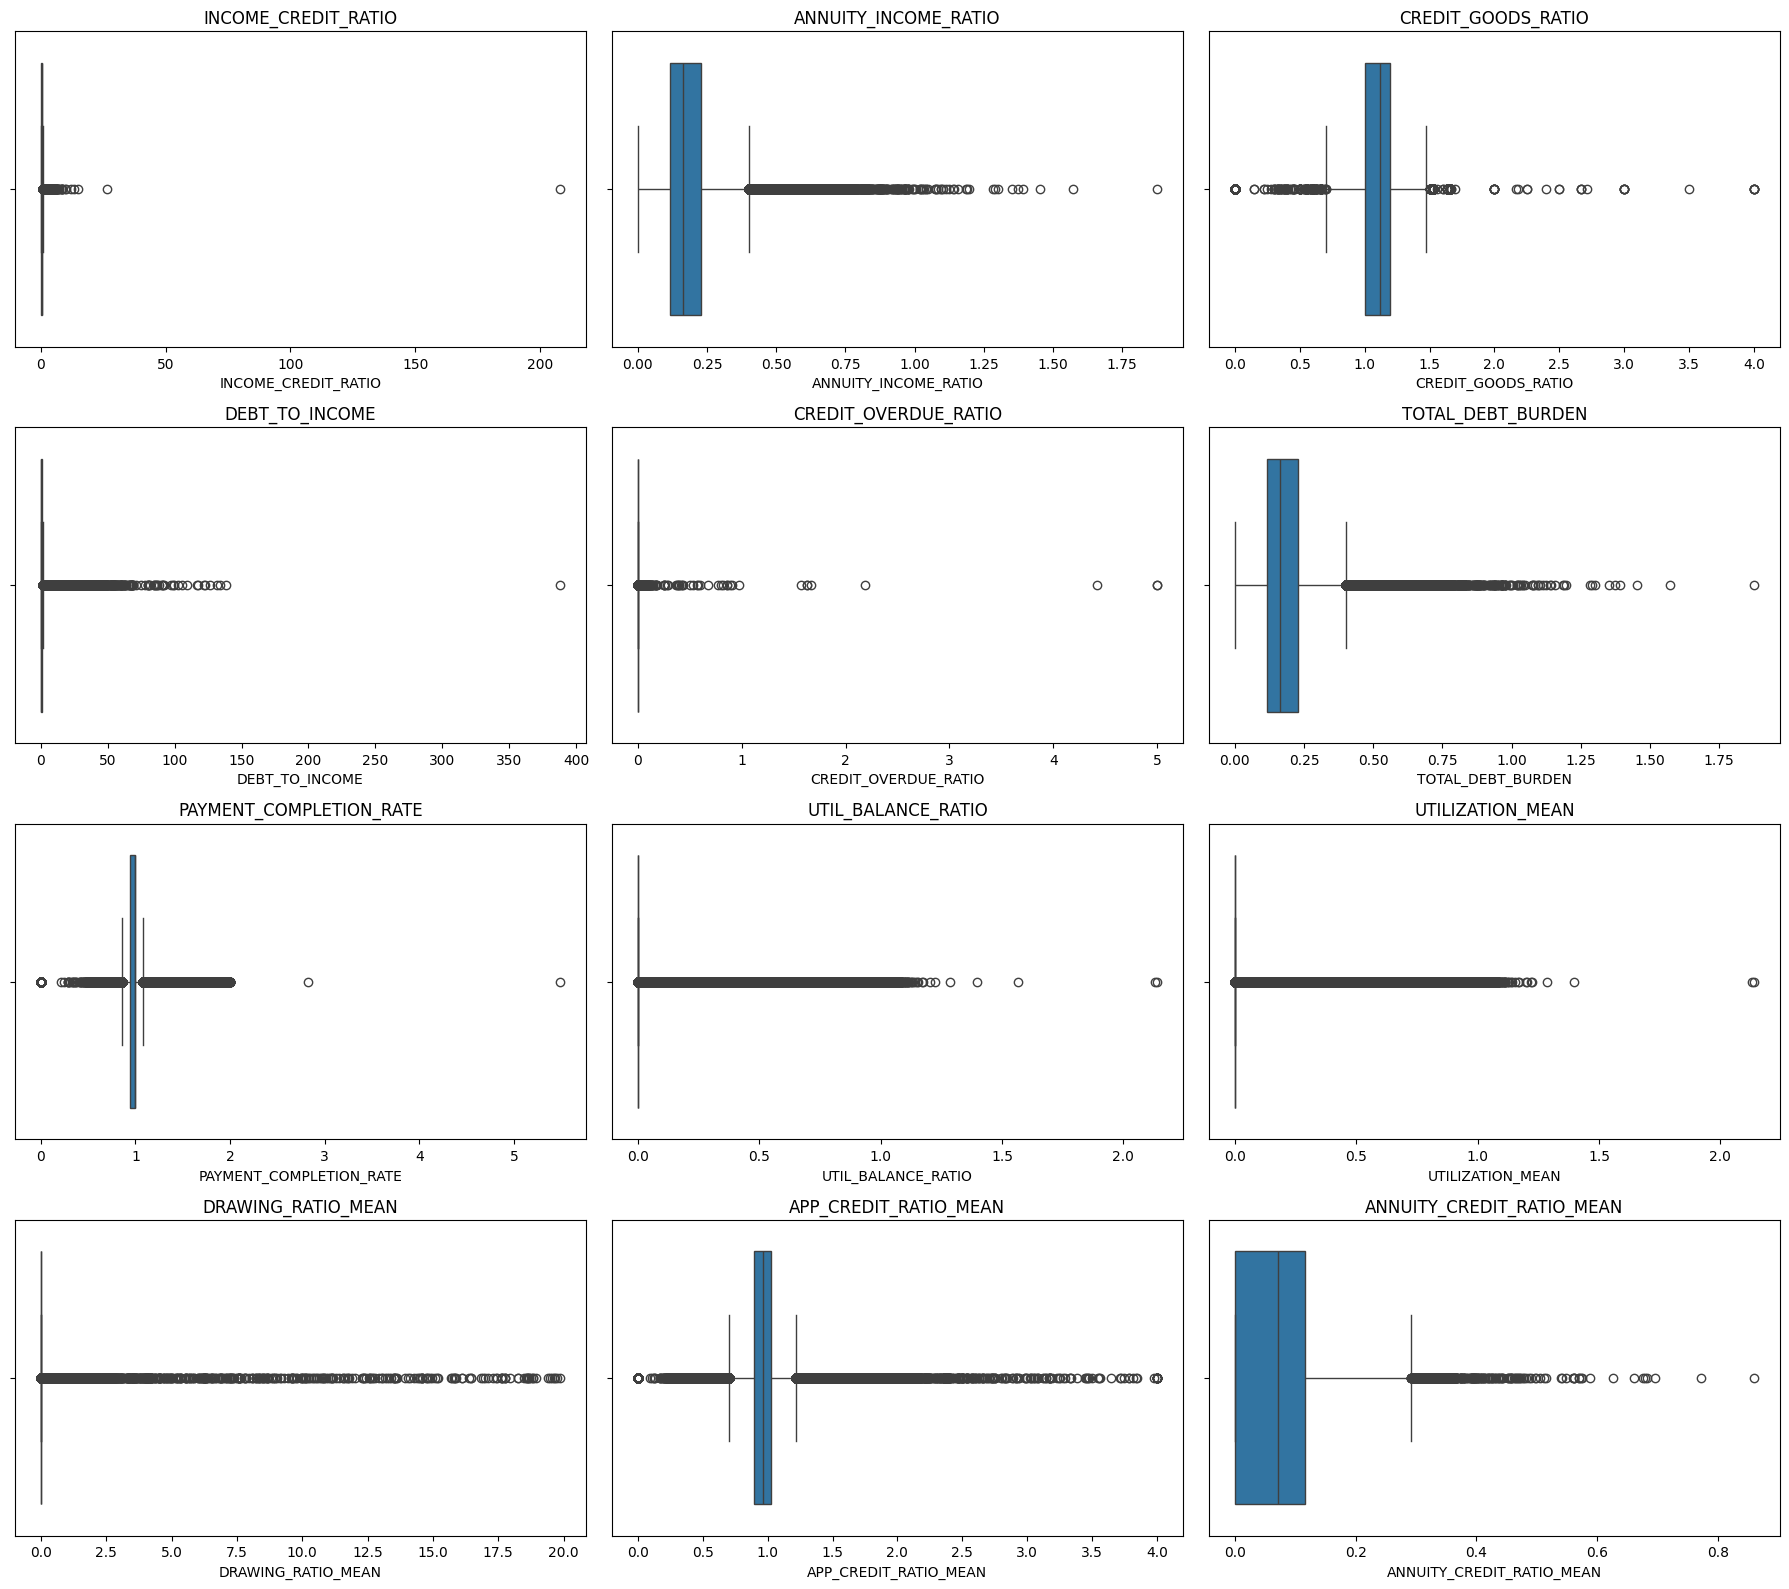

In [75]:
import math

cols = ['INCOME_CREDIT_RATIO', 'ANNUITY_INCOME_RATIO','CREDIT_GOODS_RATIO','DEBT_TO_INCOME',
'CREDIT_OVERDUE_RATIO','TOTAL_DEBT_BURDEN','PAYMENT_COMPLETION_RATE',
'UTIL_BALANCE_RATIO','UTILIZATION_MEAN',
'DRAWING_RATIO_MEAN','APP_CREDIT_RATIO_MEAN',
'ANNUITY_CREDIT_RATIO_MEAN']

# layout
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

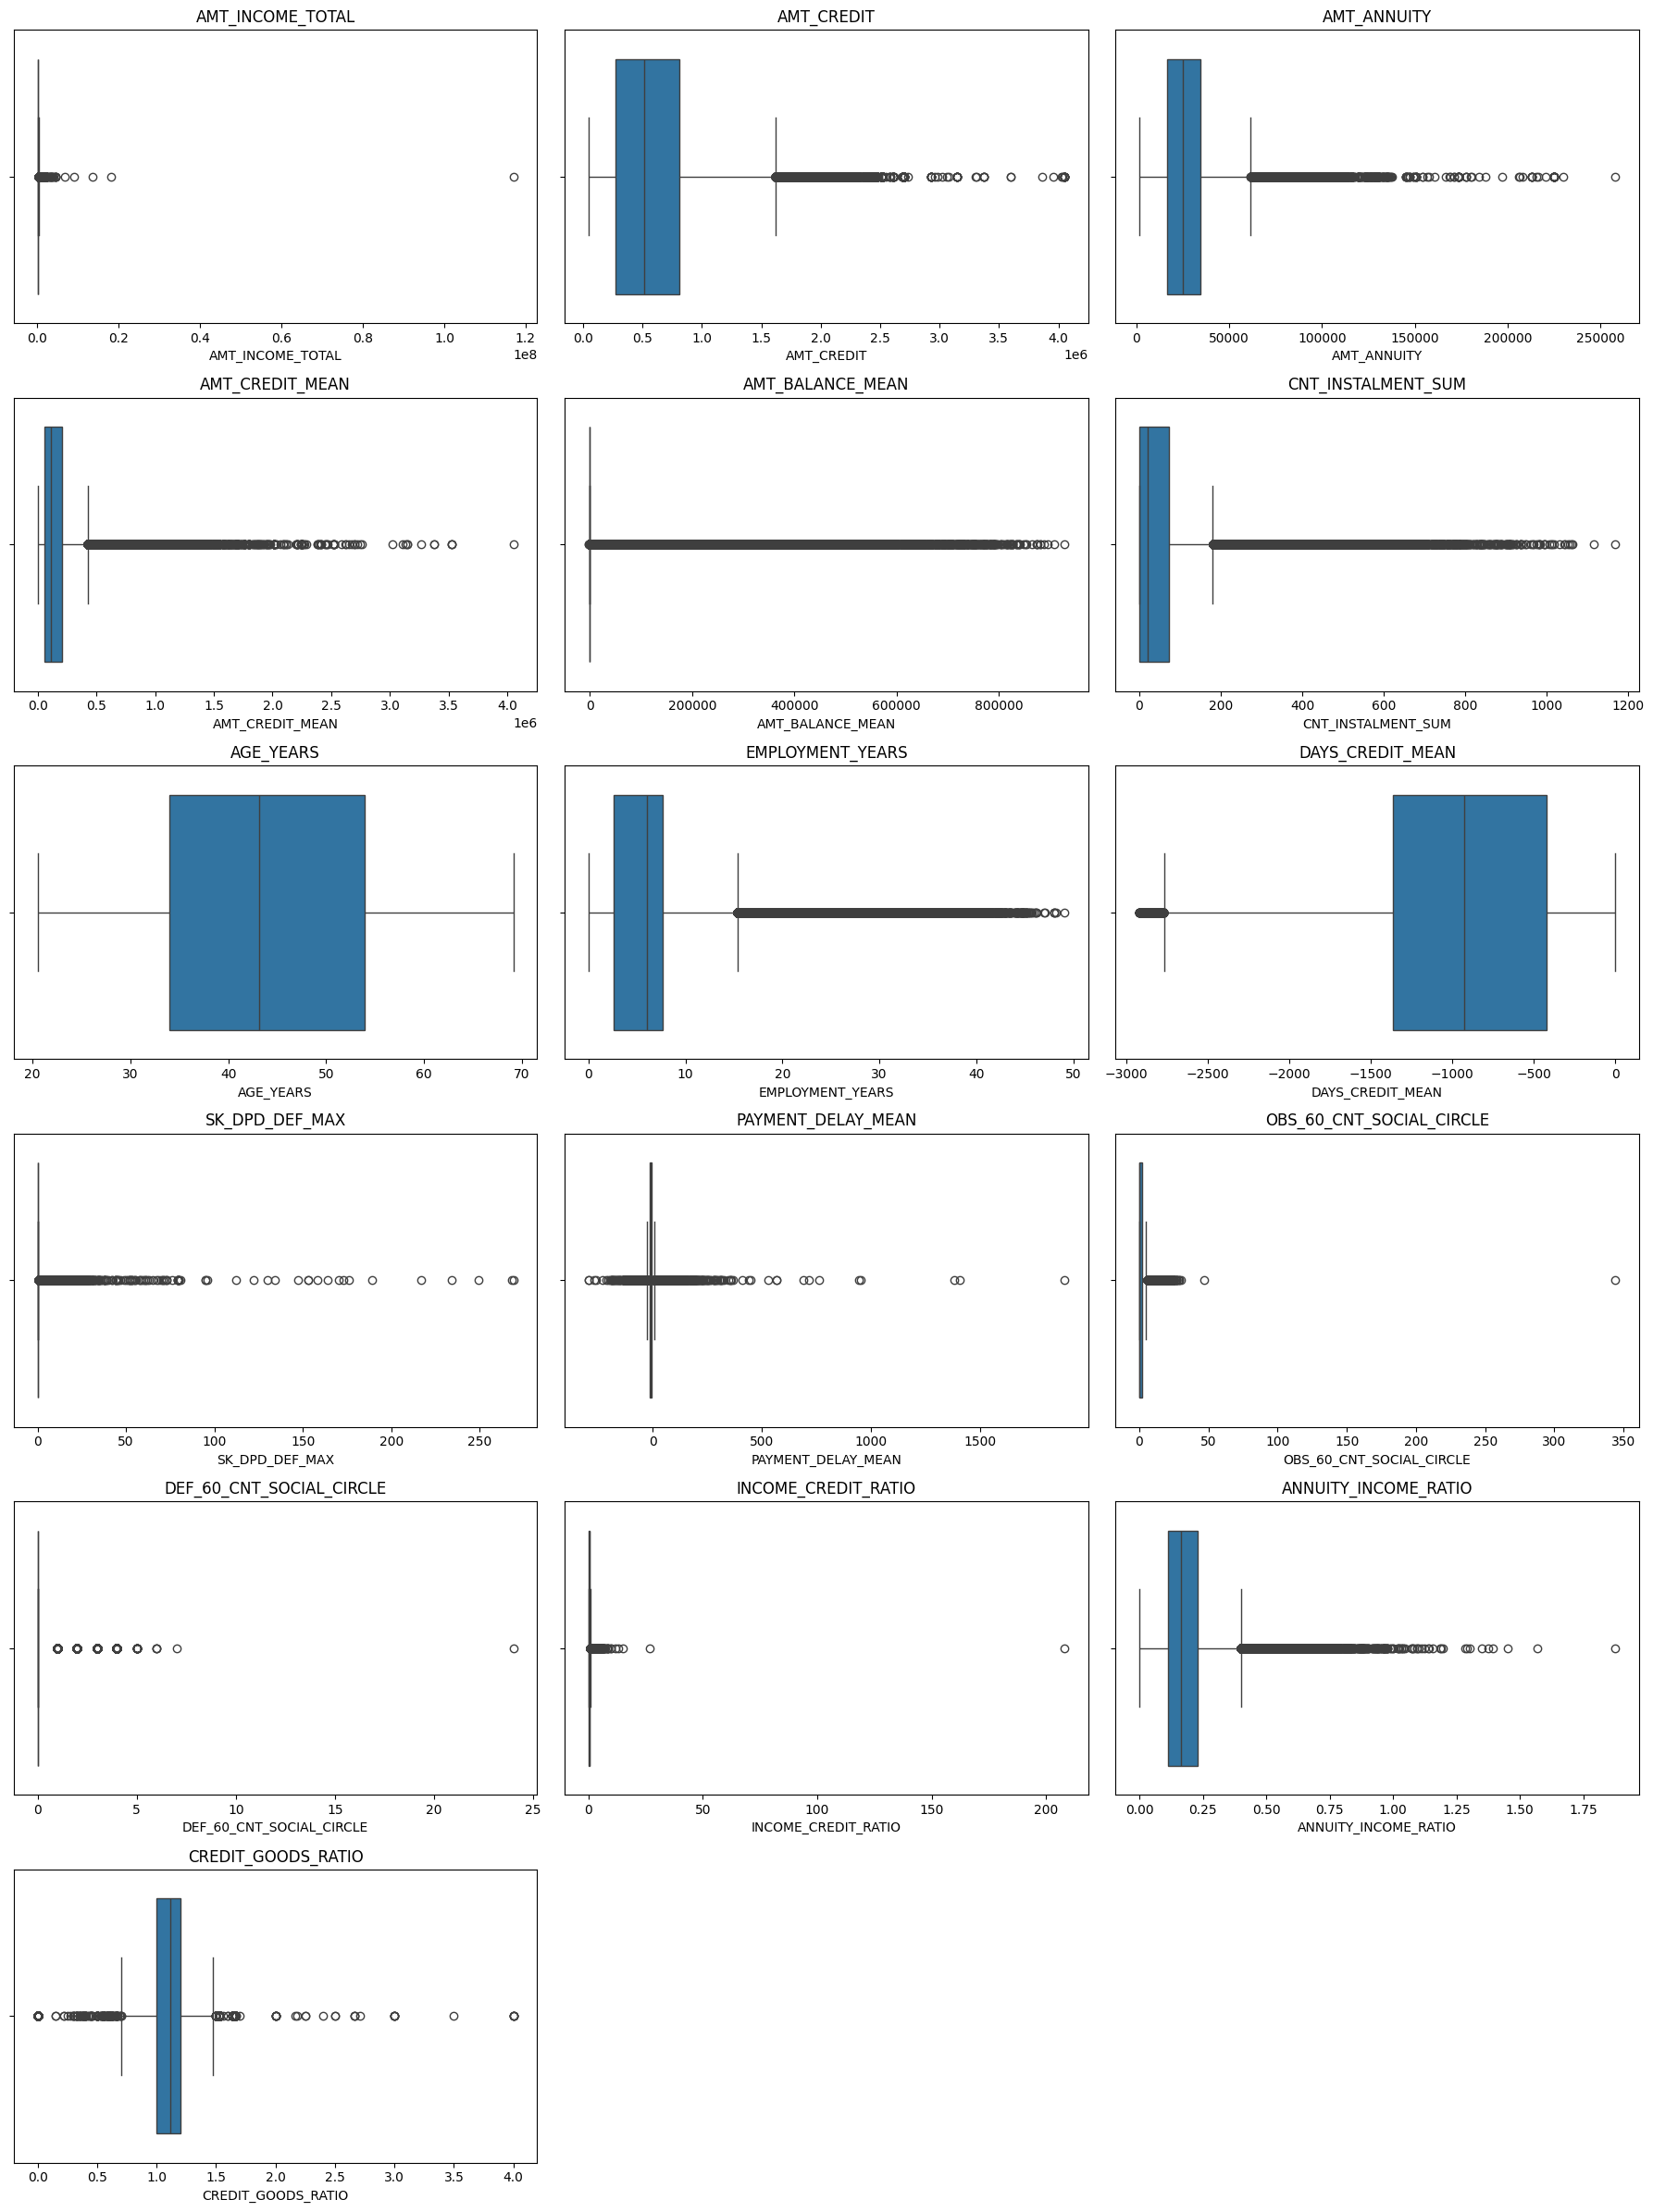

In [78]:
import math

cols = [
    'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
    'AMT_CREDIT_MEAN','AMT_BALANCE_MEAN',
    'CNT_INSTALMENT_SUM',
    'AGE_YEARS','EMPLOYMENT_YEARS','DAYS_CREDIT_MEAN',
    'SK_DPD_DEF_MAX','PAYMENT_DELAY_MEAN',
    'OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE',
    'INCOME_CREDIT_RATIO','ANNUITY_INCOME_RATIO','CREDIT_GOODS_RATIO'
]

# layout
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

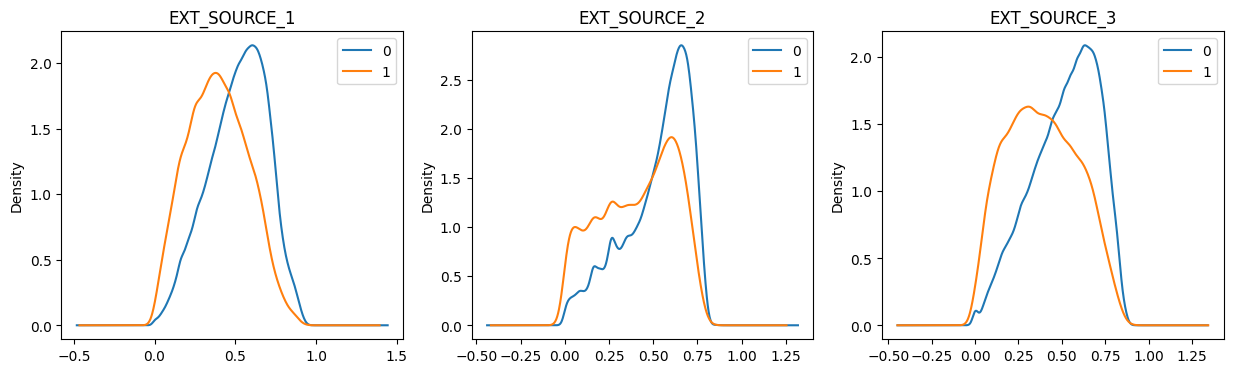

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    df_train.groupby('TARGET')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(col)

Text(0.5, 1.0, 'Default Rate by Income Type')

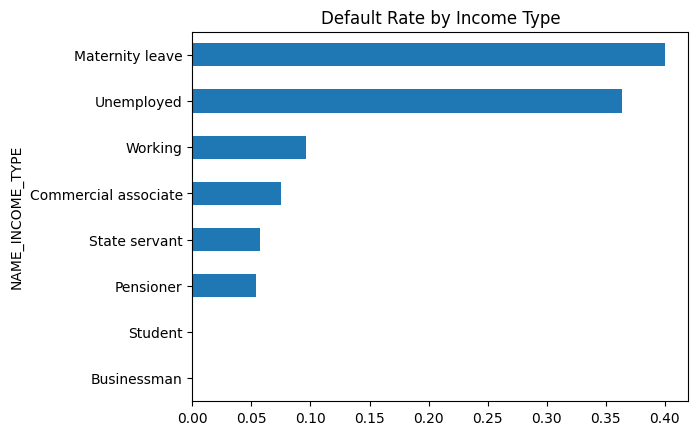

In [80]:
df_train.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values().plot(kind='barh')
plt.title('Default Rate by Income Type')

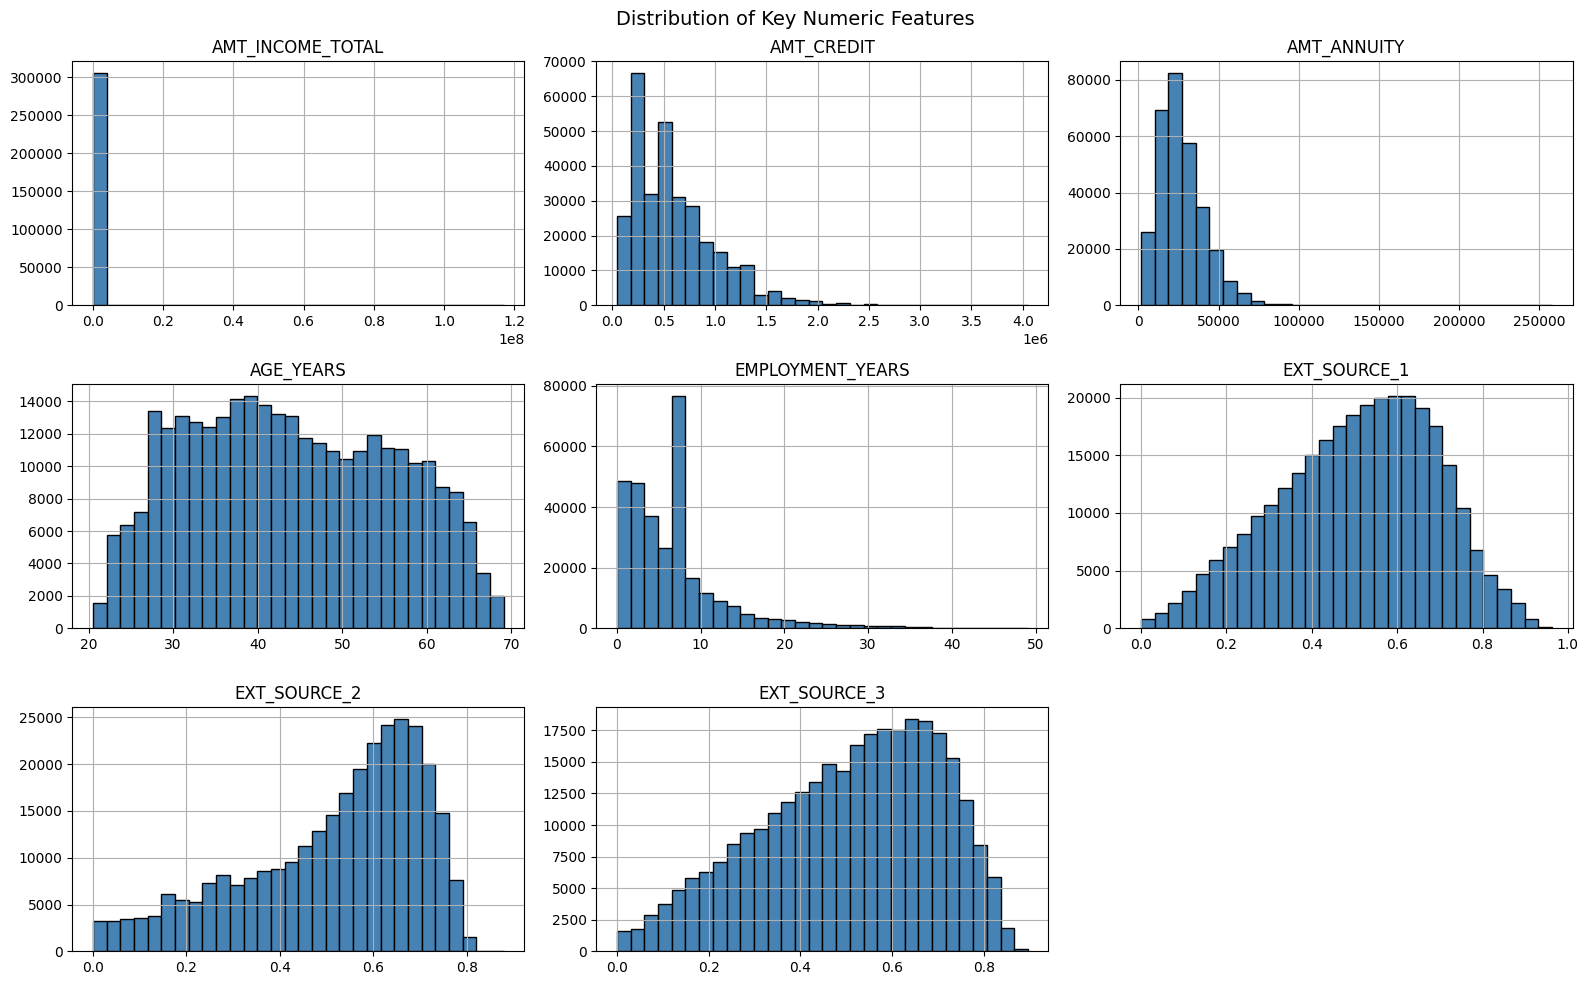

In [81]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
            'AGE_YEARS', 'EMPLOYMENT_YEARS', 'EXT_SOURCE_1', 
            'EXT_SOURCE_2', 'EXT_SOURCE_3']

df_train[num_cols].hist(figsize=(16, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

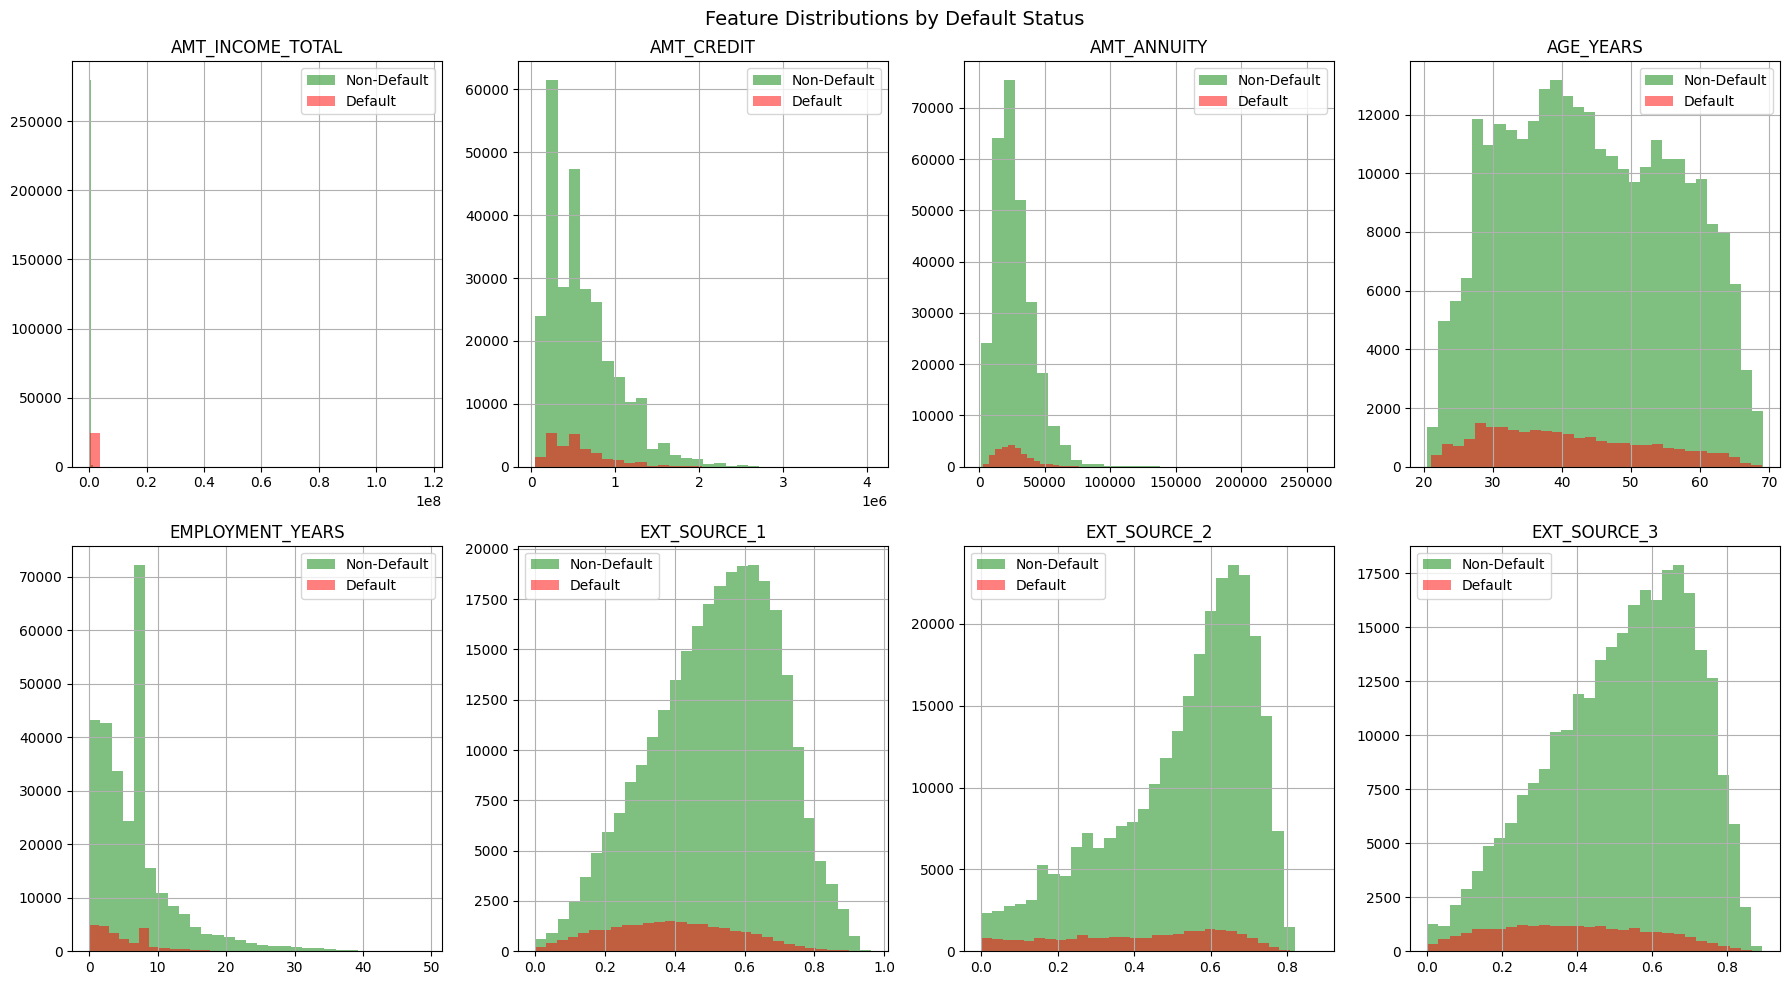

In [82]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_train[df_train['TARGET']==0][col].hist(ax=axes[i], bins=30, alpha=0.5, label='Non-Default', color='green')
    df_train[df_train['TARGET']==1][col].hist(ax=axes[i], bins=30, alpha=0.5, label='Default', color='red')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Default Status', fontsize=14)
plt.tight_layout()
plt.show()

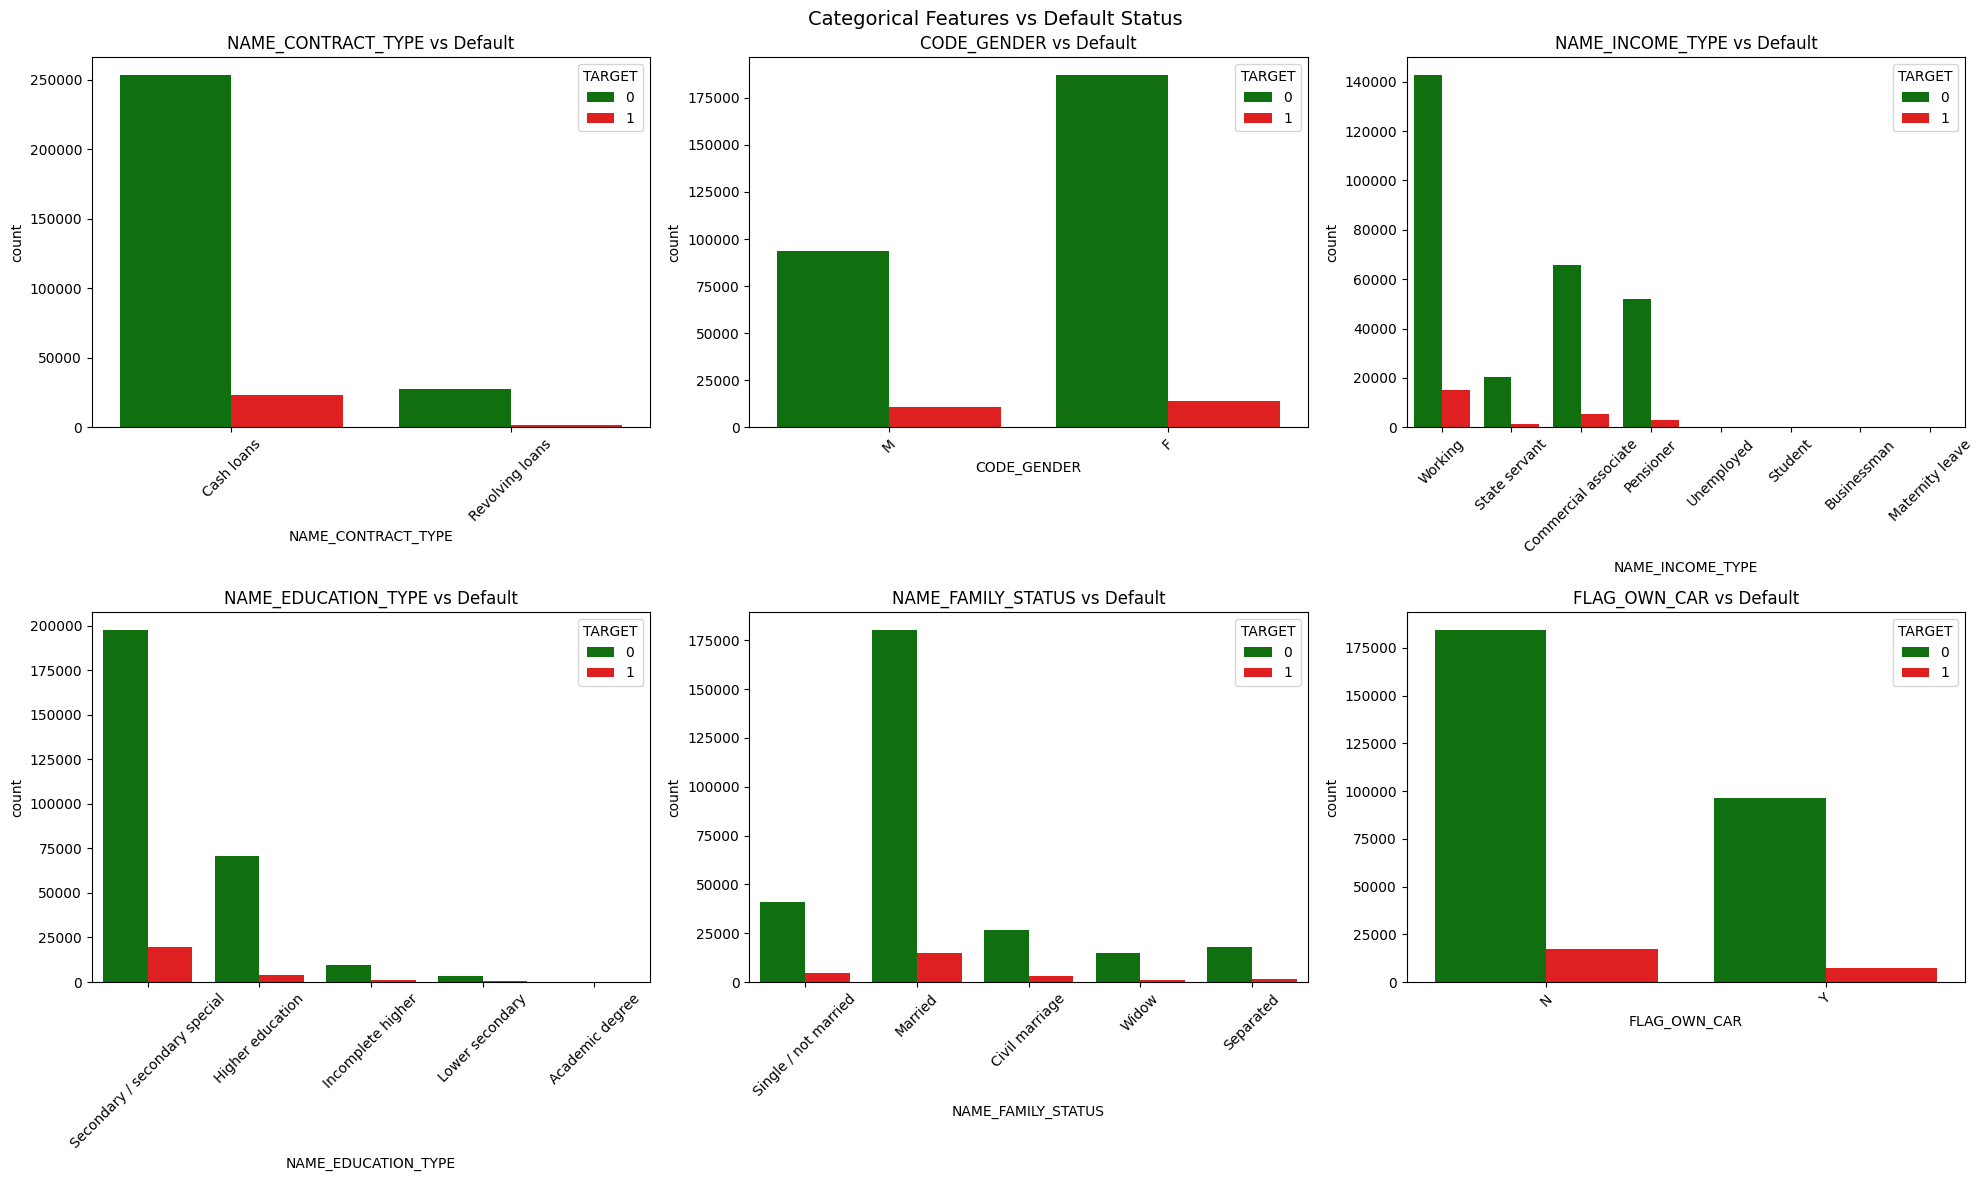

In [83]:
cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'NAME_FAMILY_STATUS', 'FLAG_OWN_CAR']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_train, x=col, hue='TARGET', ax=axes[i], palette=['green','red'])
    axes[i].set_title(f'{col} vs Default')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Default Status', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
df_train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'PAYMENT_COMPLETION_RATE', 'DELAY_TO_CREDIT_RATIO',
       'SOCIAL_CIRCLE_DEFAULT_RATE', 'UTIL_BALANCE_RATIO',
       'DRAWING_TO_PAYMENT', 'IS_EMPLOYED', 'RECENTLY_CHANGED_PHONE',
       'HAS_CAR_AND_REALTY', 'OCCUPATION_TYPE_MISSING',
       'NAME_TYPE_SUITE_MISSING'],
      dtype='str', length=132)

In [70]:
list(df_train.columns)

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',

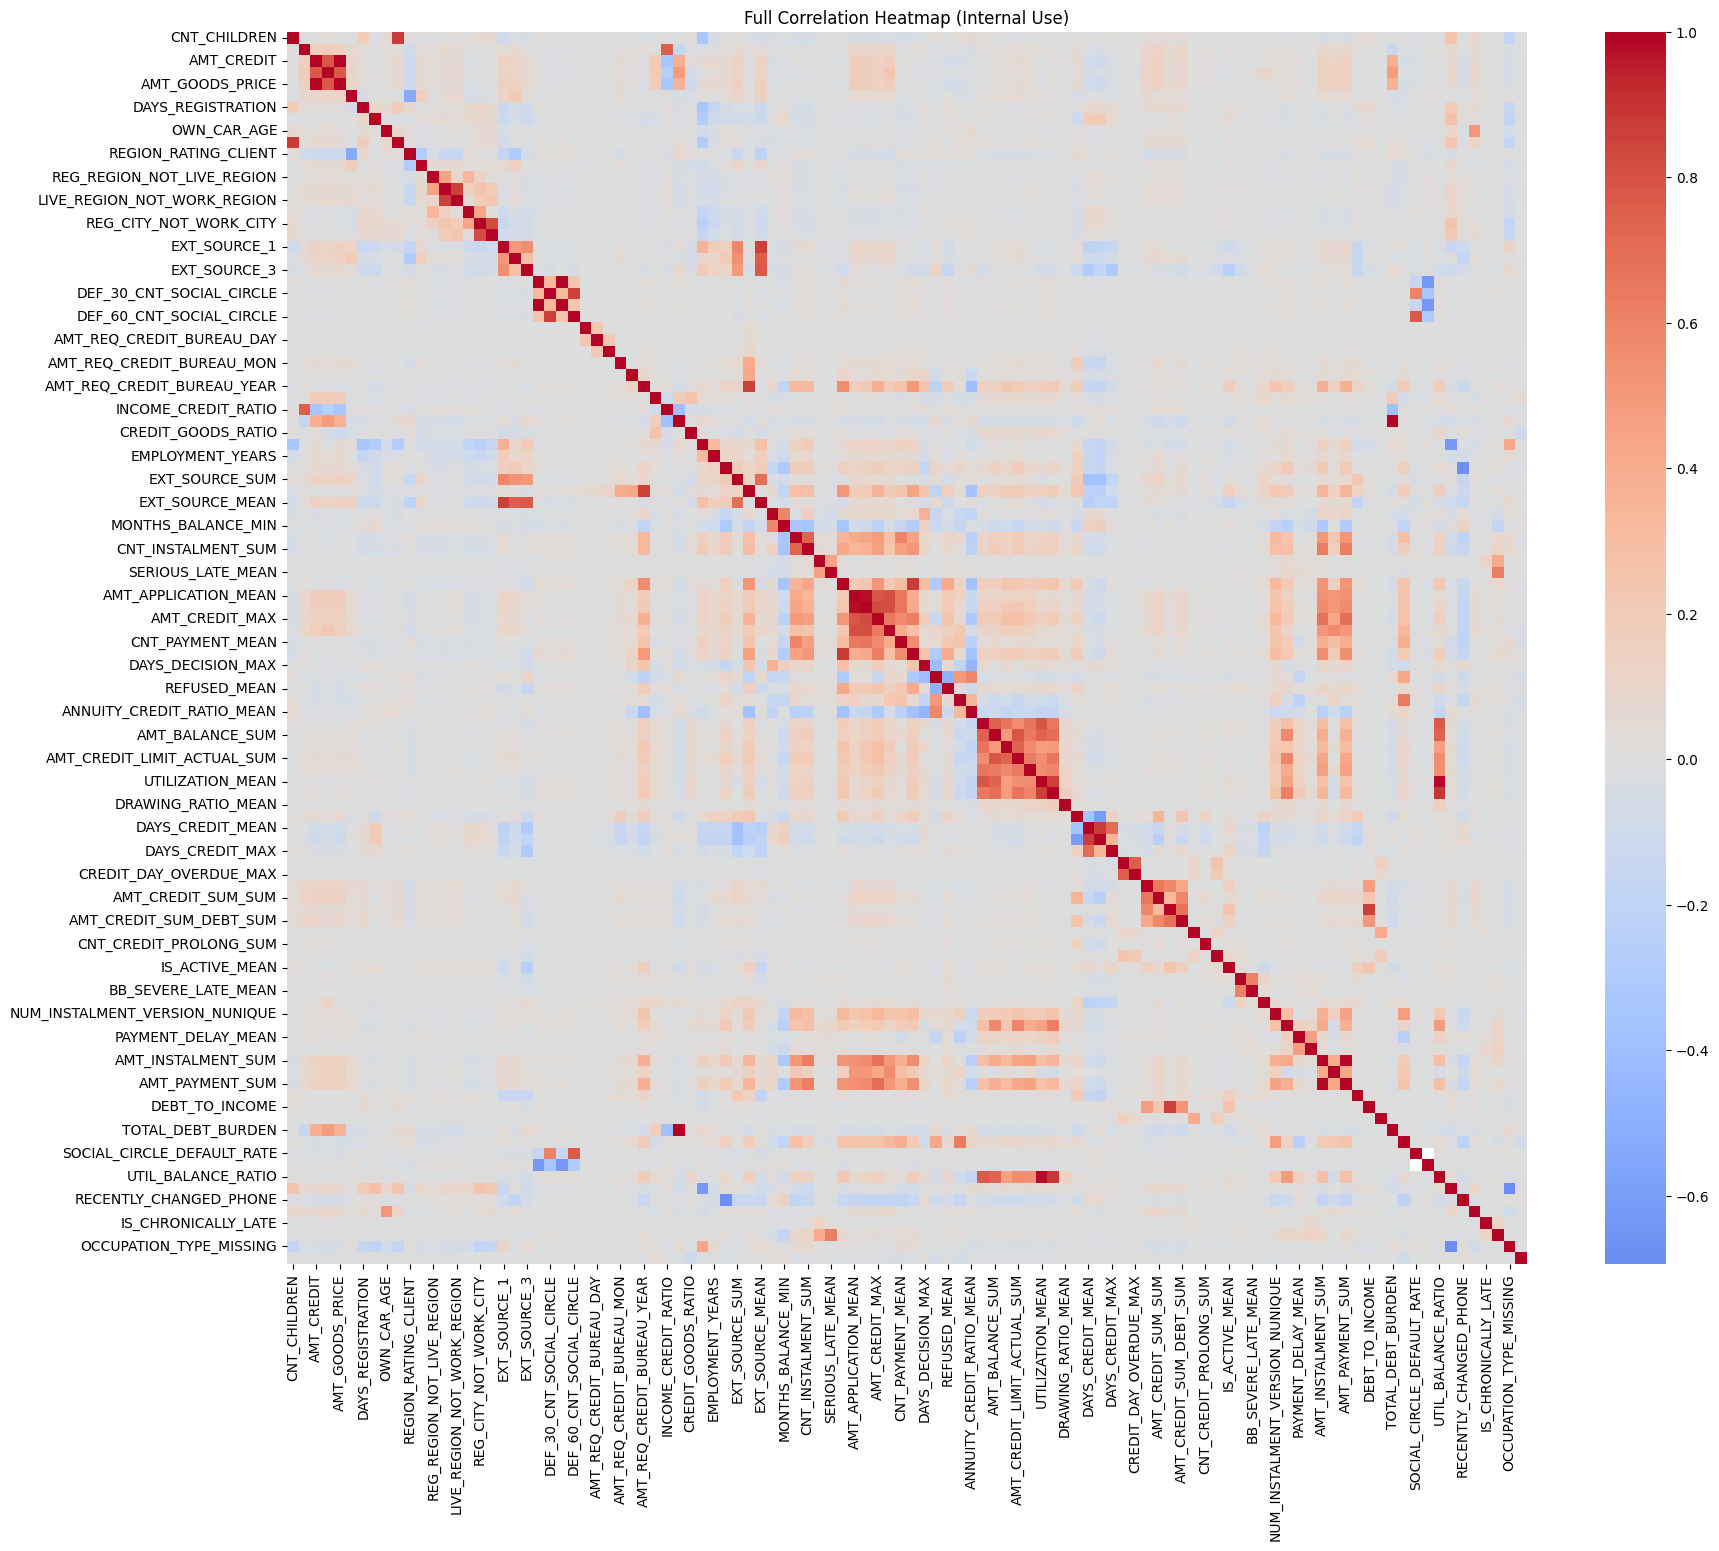

In [71]:
num_cols = df_train.select_dtypes(include=['int64','float64']).columns.tolist()

# remove target + ID
num_cols = [c for c in num_cols if c not in ['TARGET','SK_ID_CURR']]

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df_train.select_dtypes(include=['int64','float64']).columns
num_cols = [c for c in num_cols if c not in ['TARGET','SK_ID_CURR']]

plt.figure(figsize=(20, 16))
sns.heatmap(df_train[num_cols].corr(), cmap='coolwarm', center=0)
plt.title("Full Correlation Heatmap (Internal Use)")
plt.show()

In [73]:
corr_matrix = df_train[num_cols].corr()

In [74]:
import numpy as np

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, corr_val))

len(high_corr_pairs)

20

In [76]:
for pair in high_corr_pairs[:20]:  # first 20
    print(pair)

('CNT_CHILDREN', 'CNT_FAM_MEMBERS', np.float64(0.8791801821329801))
('AMT_CREDIT', 'AMT_GOODS_PRICE', np.float64(0.9869753997649064))
('REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', np.float64(0.8607878891669584))
('REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', np.float64(0.825499844963529))
('EXT_SOURCE_1', 'EXT_SOURCE_MEAN', np.float64(0.8592229026322231))
('OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', np.float64(0.998493930821181))
('DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', np.float64(0.8604597080536653))
('AMT_REQ_CREDIT_BUREAU_YEAR', 'TOTAL_BUREAU_REQUESTS', np.float64(0.8625625777985665))
('ANNUITY_INCOME_RATIO', 'TOTAL_DEBT_BURDEN', np.float64(0.9999409864442789))
('SK_ID_PREV_NUNIQUE', 'CNT_PAYMENT_SUM', np.float64(0.8792843548744678))
('AMT_APPLICATION_MEAN', 'AMT_CREDIT_MEAN', np.float64(0.9771938759760667))
('AMT_APPLICATION_MEAN', 'AMT_ANNUITY_MEAN', np.float64(0.8119609160184317))
('AMT_CREDIT_MEAN', 'AMT_CREDIT_MAX', np.float64(

In [86]:
drop_cols = [

 # duplicates / strong collinearity
 'CNT_FAM_MEMBERS',
 'AMT_GOODS_PRICE',   # optional drop (recommended)

 # region duplicates
 'LIVE_REGION_NOT_WORK_REGION',
 'LIVE_CITY_NOT_WORK_CITY',

 # duplicate social window
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',

 # redundant engineered
 'EXT_SOURCE_SUM',
 'TOTAL_BUREAU_REQUESTS',

 # prev app redundancy
 'AMT_APPLICATION_MEAN',

 # correlated credit features
 'UTILIZATION_MAX',
 'DAYS_CREDIT_MIN',

 # duplicate debt signals
 'AMT_CREDIT_SUM_DEBT_MEAN',

 # duplicate counts
 'CNT_PAYMENT_SUM',

 # duplicate column bug
 'SK_ID_PREV_NUNIQUE.1'
]

df_train = df_train.drop(columns=drop_cols, errors='ignore')
df_test = df_test.drop(columns=drop_cols, errors='ignore')

In [220]:
df_train.to_csv("cleaned_train.csv", index=False)
df_test.to_csv("cleaned_test.csv", index=False)

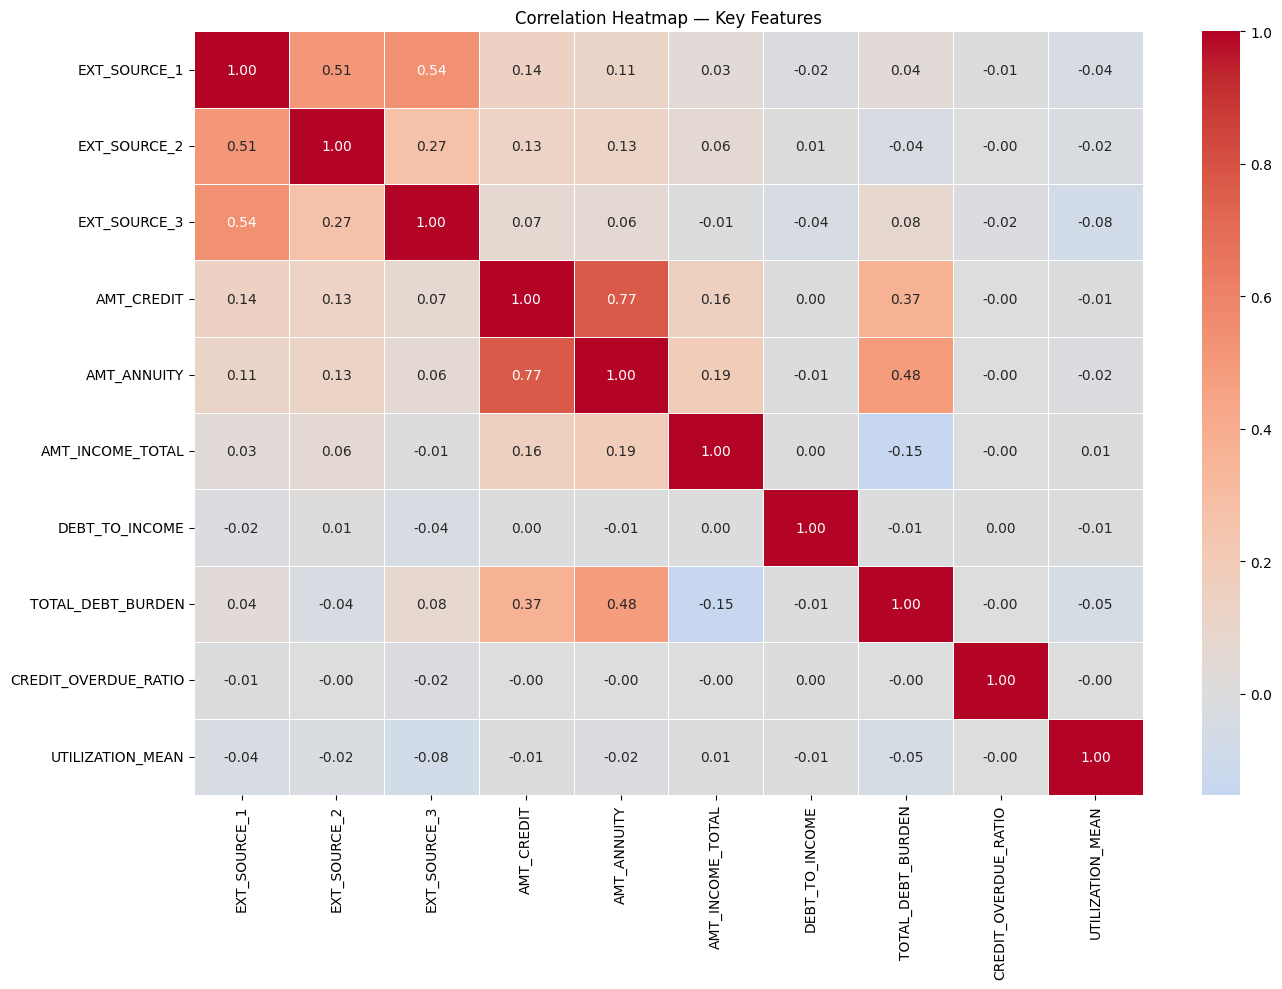

In [88]:
top_num_cols = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3',
    'AMT_CREDIT','AMT_ANNUITY','AMT_INCOME_TOTAL',
    'DEBT_TO_INCOME','TOTAL_DEBT_BURDEN',
    'CREDIT_OVERDUE_RATIO','UTILIZATION_MEAN'
            ]

plt.figure(figsize=(14, 10))
sns.heatmap(df_train[top_num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Key Features')
plt.tight_layout()
plt.show()

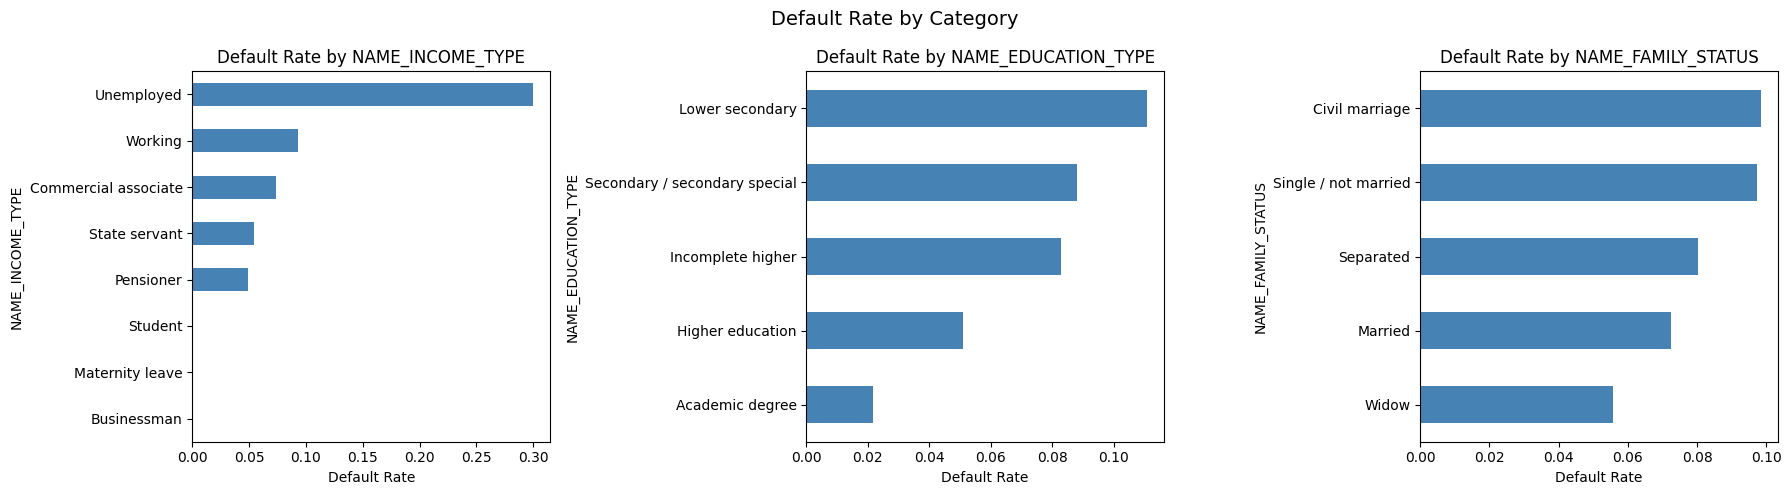

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']):
    df_train.groupby(col)['TARGET'].mean().sort_values().plot(
        kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate')

plt.suptitle('Default Rate by Category', fontsize=14)
plt.tight_layout()
plt.show()

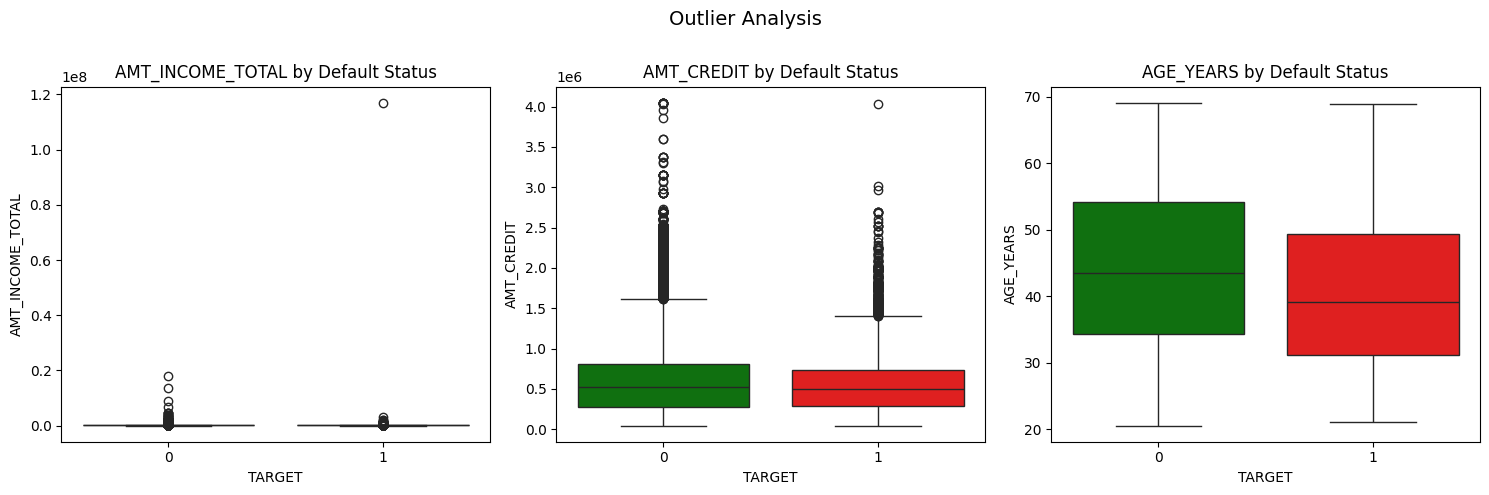

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AGE_YEARS']):
    sns.boxplot(data=df_train, x='TARGET', y=col, ax=axes[i], 
                palette=['green', 'red'])
    axes[i].set_title(f'{col} by Default Status')

plt.suptitle('Outlier Analysis', fontsize=14)
plt.tight_layout()
plt.show()

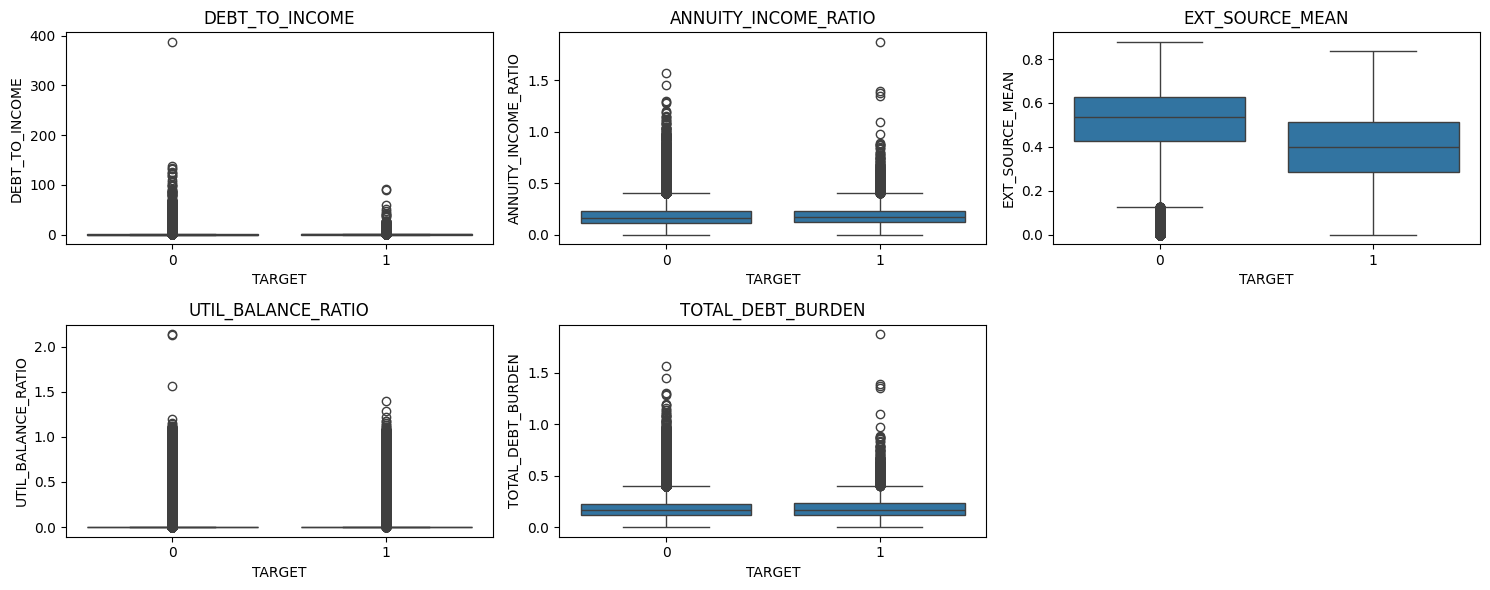

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'DEBT_TO_INCOME',
    'ANNUITY_INCOME_RATIO',
    'EXT_SOURCE_MEAN',
    'UTIL_BALANCE_RATIO',
    'TOTAL_DEBT_BURDEN'
]

plt.figure(figsize=(15,6))

for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_train['TARGET'], y=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
df_train[df_train['DEBT_TO_INCOME'] > 10]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,TOTAL_DEBT_BURDEN,DELAY_TO_CREDIT_RATIO,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING
24,100029,0.0,Cash loans,M,Y,N,2,135000.0,247500.0,12703.5,...,0.094099,-2.821429,0.000000,0,0.000000,1,1,0,0,0
37,100047,1.0,Cash loans,M,N,Y,0,202500.0,1193580.0,35028.0,...,0.172977,-0.166216,NaN,1,0.000000,1,0,0,0,0
54,100076,0.0,Cash loans,M,Y,N,0,180000.0,315000.0,9679.5,...,0.053775,0.000000,NaN,1,0.000000,1,1,0,0,1
90,100129,0.0,Revolving loans,F,Y,Y,1,85500.0,135000.0,6750.0,...,0.078946,0.000000,NaN,1,0.000000,1,1,1,1,0
97,100136,0.0,Cash loans,M,Y,N,1,157500.0,1571931.0,49356.0,...,0.313369,-0.452862,NaN,1,0.000000,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257572,456235,0.0,Cash loans,M,Y,Y,2,90000.0,1078200.0,31522.5,...,0.350246,-0.610845,0.000000,0,0.000000,1,0,1,0,0
257576,456239,0.0,Cash loans,M,Y,N,0,180000.0,808650.0,23773.5,...,0.132074,-1.350000,NaN,1,0.649077,1,0,0,0,0
257578,456243,0.0,Cash loans,F,N,Y,0,81000.0,225000.0,12694.5,...,0.156720,-1.763955,0.000000,0,0.000000,1,0,0,0,0
257581,456247,0.0,Cash loans,F,N,Y,0,112500.0,345510.0,17770.5,...,0.157959,-0.417444,0.222222,0,0.161225,1,0,0,0,0


In [16]:
outliers[['AMT_PAYMENT_SUM','AMT_INSTALMENT_MEAN','CNT_PAYMENT_MEAN']].describe()

,AMT_PAYMENT_SUM,AMT_INSTALMENT_MEAN,CNT_PAYMENT_MEAN
count,1.661000e+04,16610.000000,16610.000000
mean,1.225773e+06,9429.213272,8.269288
std,1.271349e+06,8438.229101,5.393359
min,7.344000e+01,0.000000,0.000000
25%,4.060736e+05,4475.693507,5.000000
50%,8.048214e+05,7199.180083,8.500000
75%,1.598549e+06,11992.191225,12.000000
max,1.678127e+07,341031.330000,60.000000


Text(0.5, 1.0, 'Income vs Credit')

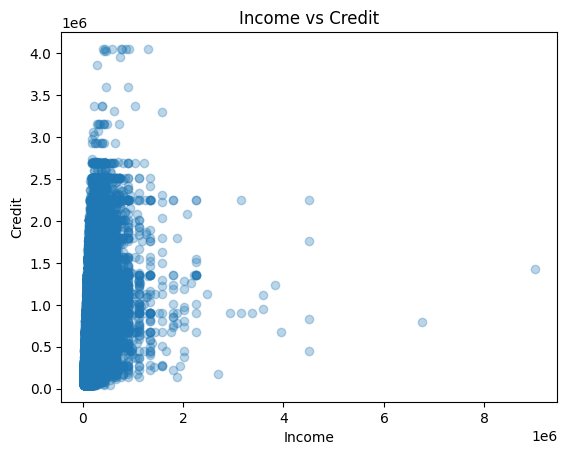

In [68]:
plt.scatter(df_train['AMT_INCOME_TOTAL'], df_train['AMT_CREDIT'], alpha=0.3)
plt.xlabel('Income')
plt.ylabel('Credit')
plt.title('Income vs Credit')

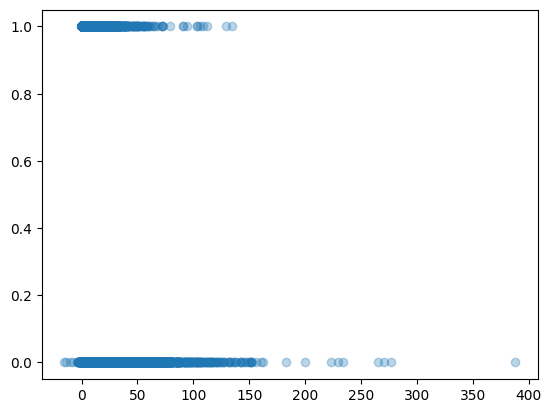

In [69]:
plt.scatter(df_train['DEBT_TO_INCOME'], df_train['TARGET'], alpha=0.3)

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_MEAN'>

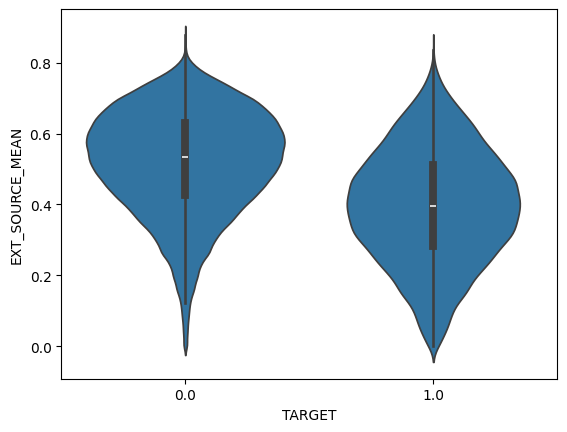

In [70]:
import seaborn as sns
sns.violinplot(x='TARGET', y='EXT_SOURCE_MEAN', data=df_train)

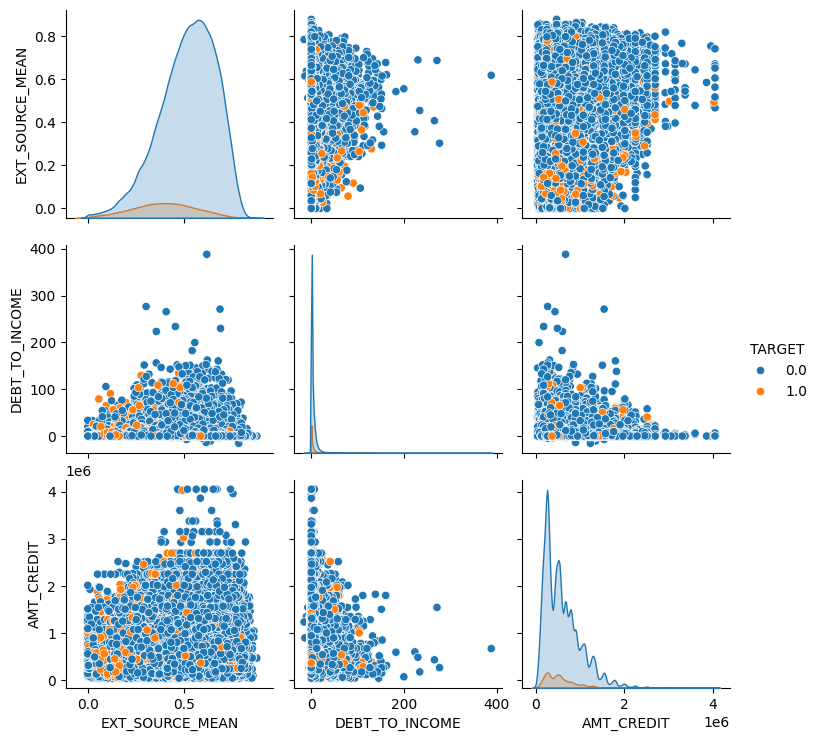

In [81]:
cols = ['EXT_SOURCE_MEAN', 'DEBT_TO_INCOME', 'AMT_CREDIT', 'TARGET']
sns.pairplot(df_train[cols], hue='TARGET')

sns.boxplot(x='TARGET', y='DEBT_TO_INCOME', data=df)

In [7]:
X = df_train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_train['TARGET']

In [8]:
X = pd.get_dummies(X)

In [9]:
# 2. CLEAN COLUMN NAMES (do this FIRST before anything)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

# 3. UNDERSAMPLE
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy={0: 20255, 1: 20255}, random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

# 4. SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus,
    test_size=0.2,
    random_state=42,
    stratify=y_rus)

# 5. MODEL
import lightgbm as lgb
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=1,
    random_state=42
)

# 6. TRAIN
model.fit(X_train, y_train)

# 7. PREDICT
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 8. EVALUATE
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 16204, number of negative: 16204
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059944 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14310
[LightGBM] [Info] Number of data points in the train set: 32408, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      4051
           1       0.70      0.70      0.70      4051

    accuracy                           0.70      8102
   macro avg       0.70      0.70      0.70      8102
weighted avg       0.70      0.70      0.70      8102

AUC-ROC: 0.7694585956967694


# 5. MODEL (CatBoost)
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# 6. TRAIN
model.fit(X_train, y_train)

# 7. PREDICT
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 8. EVALUATE
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

from catboost import Pool

pool_test = Pool(X_test)

shap_values = model.get_feature_importance(
    data=pool_test,
    type='ShapValues'
)

import pandas as pd
import numpy as np

shap_df = pd.DataFrame(shap_values[:, :-1], columns=X_test.columns)

shap_importance = np.abs(shap_df).mean().sort_values(ascending=False)

print(shap_importance.head(20))

# pick one row
row_idx = 99

row_shap = shap_df.iloc[row_idx].sort_values(key=abs, ascending=False)

print(row_shap.head(10))

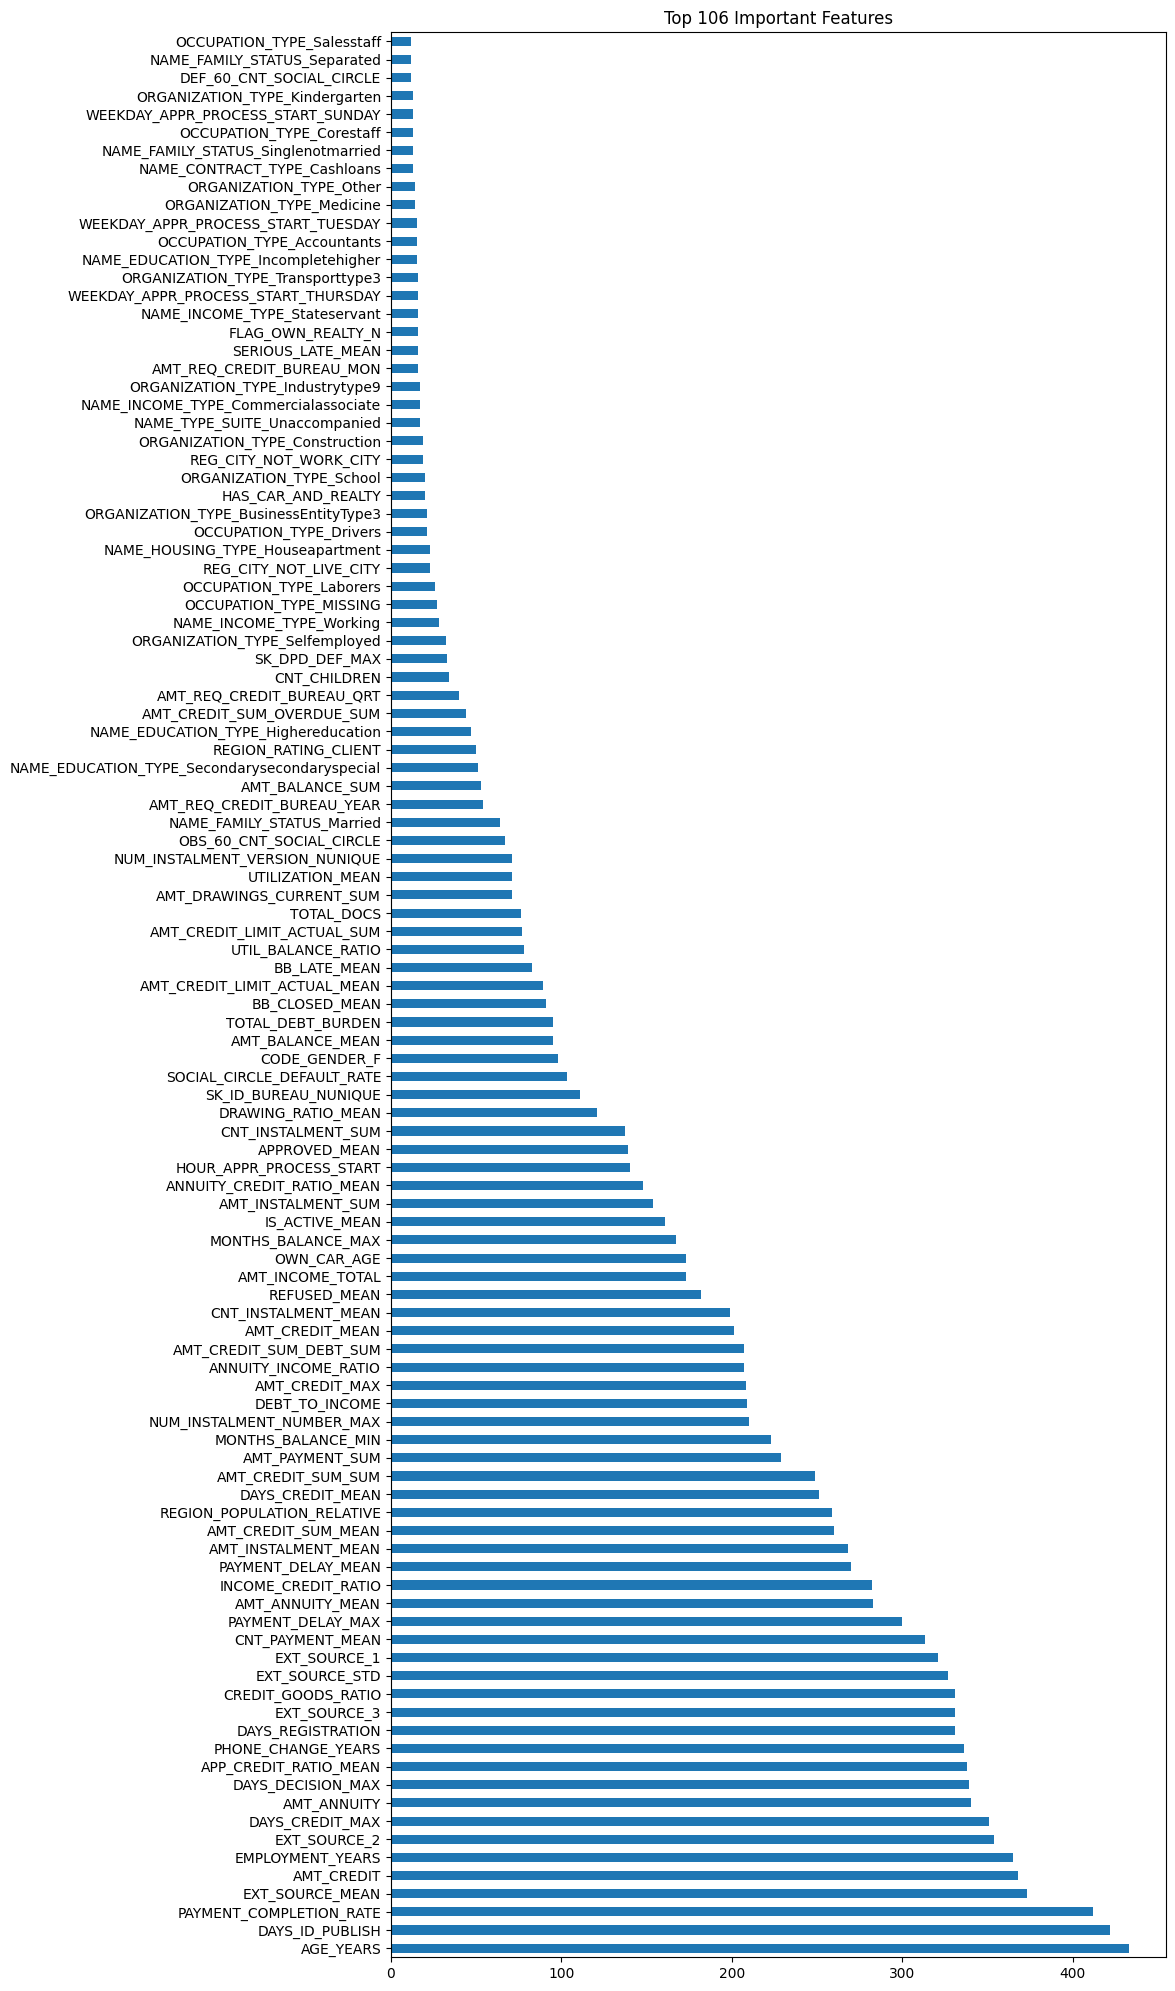

In [49]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.nlargest(106).plot(kind='barh', figsize=(10,25))
plt.title('Top 106 Important Features')
plt.savefig('important features ranked.png')

Text(0.5, 1.0, 'Confusion Matrix')

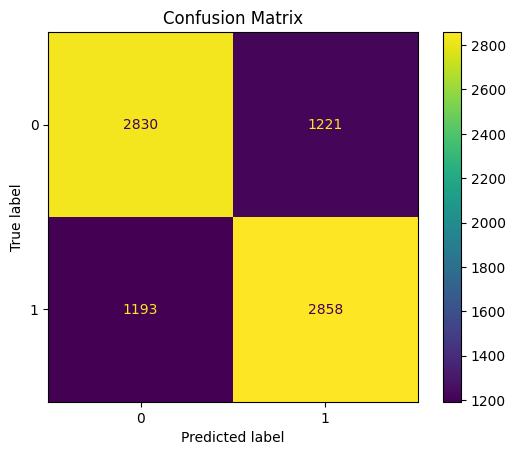

In [110]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')

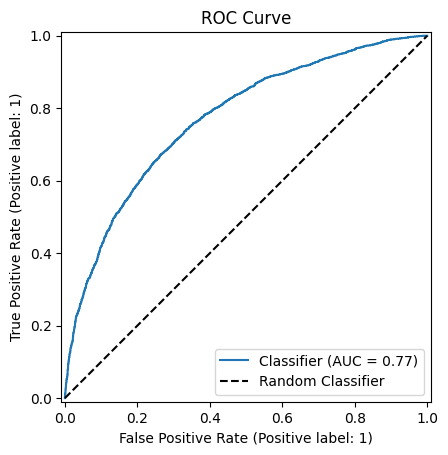

In [111]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

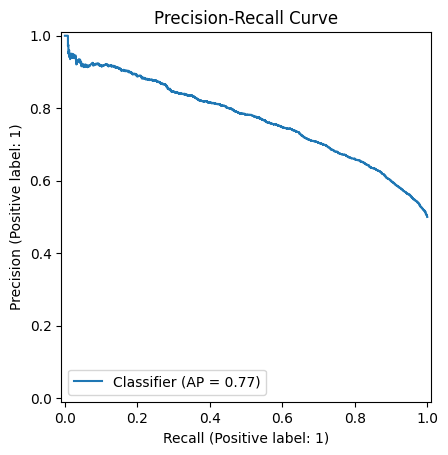

In [106]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision-Recall Curve')
plt.show()

In [10]:
# Save medians when training
feature_medians = X_train.median()
feature_medians.to_csv('feature_medians.csv')

In [11]:
df_test = df_test[df_train.drop(columns=['TARGET']).columns]

In [12]:
df_train['TARGET'].value_counts()

TARGET
0    281051
1     24670
Name: count, dtype: int64

In [42]:
df_train.to_csv('cleaned_train.csv', index=False)
df_test.to_csv('cleaned_test.csv', index=False)

with open('home_credit_default_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved!")

import pickle

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Columns saved!")

In [13]:
X = df_train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_train['TARGET']

In [14]:
X = pd.get_dummies(X)

In [15]:
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

In [16]:
# undersample
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

X_res, y_res = rus.fit_resample(X, y)

# train
model.fit(X_res, y_res)

[LightGBM] [Info] Number of positive: 24670, number of negative: 24670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14905
[LightGBM] [Info] Number of data points in the train set: 49340, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
df_test_processed = pd.get_dummies(df_test)
df_test_processed.columns = df_test_processed.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
# Align columns with training
df_test_processed = df_test_processed.reindex(columns=X.columns, fill_value=0)

In [18]:
# predict (ONLY THIS)
df_test['PRED'] = model.predict_proba(df_test_processed)[:,1]

# select medium
medium = df_test[
    (df_test['PRED'] > 0.35) &
    (df_test['PRED'] < 0.6)
].head(1)

In [19]:
df_test['PRED'].describe()

count    48744.000000
mean         0.405111
std          0.216945
min          0.022705
25%          0.222611
50%          0.372821
75%          0.570213
max          0.985410
Name: PRED, dtype: float64

In [28]:
medium

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,DELAY_TO_CREDIT_RATIO,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING,PRED
9,100067,0.0,Cash loans,F,Y,Y,1,162000.0,45000.0,5337.0,...,0.0,0.0,0,0.604061,1,0,1,0,0,0.569268


In [24]:
# predict (ONLY THIS)
df_test['PRED'] = model.predict_proba(df_test_processed)[:,1]

# select low
low = df_test[
    (df_test['PRED'] > 0.1) &
    (df_test['PRED'] < 0.2)
].head(5)

In [25]:
low

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,OCCUPATION_TYPE_MISSING,NAME_TYPE_SUITE_MISSING,PRED
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,NaN,...,1,0.137869,1,0,1,0,0,0,1,0.157567
6,100057,Cash loans,M,Y,Y,2,180000.0,499221.0,22117.5,Unaccompanied,...,0,0.000000,1,0,1,0,0,0,0,0.128547
8,100066,Cash loans,F,N,Y,0,315000.0,364896.0,28957.5,Unaccompanied,...,1,0.000000,1,0,0,0,0,0,0,0.107054
21,100168,Cash loans,F,N,Y,0,157500.0,266652.0,16443.0,Unaccompanied,...,1,0.000000,1,0,0,0,0,1,0,0.101578
24,100171,Cash loans,M,Y,Y,0,157500.0,539100.0,29245.5,Unaccompanied,...,0,0.360851,1,0,1,0,0,0,0,0.149007


In [29]:
df_test['PRED'] = model.predict_proba(df_test_processed)[:,1]

low = df_test[
    (df_test['PRED'] > 0.1) &
    (df_test['PRED'] < 0.2)
].head(5)
print("LOW:\n", low[['SK_ID_CURR','PRED']])

LOW:
     SK_ID_CURR      PRED
2       100013  0.157567
6       100057  0.128547
8       100066  0.107054
21      100168  0.101578
24      100171  0.149007


In [33]:
df_train['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 54853
Sales staff              31924
Core staff               27407
Managers                 21263
Drivers                  18508
High skill tech staff    11322
Accountants               9758
Medicine staff            8495
Security staff            6677
Cooking staff             5916
Cleaning staff            4631
Private service staff     2639
Low-skill Laborers        2071
Other                     1834
Waiters/barmen staff      1340
Secretaries               1297
Name: count, dtype: int64

In [35]:
med = df_test[(df_test['PRED'] > 0.3) & (df_test['PRED'] < 0.5)].head(5)
print("MEDIUM:\n", med[['SK_ID_CURR','PRED']])

MEDIUM:
     SK_ID_CURR      PRED
3       100028  0.309478
10      100074  0.311114
11      100090  0.313020
13      100092  0.473753
14      100106  0.395650


In [ ]:
df_test['PRED'] = model.predict_proba(df_test_processed)[:,1]

low = df_test[
    (df_test['PRED'] > 0.1) &
    (df_test['PRED'] < 0.2)
].head(5)
print("LOW:\n", low[['SK_ID_CURR','PRED']])

In [22]:
# predict (ONLY THIS)
df_test['PRED'] = model.predict_proba(df_test_processed)[:,1]

# select medium
high = df_test[
    (df_test['PRED'] > 0.5) &
    (df_test['PRED'] < 0.8)
].head(5)

In [34]:
high
print("HIGH:\n", high[['SK_ID_CURR','PRED']])


HIGH:
     SK_ID_CURR      PRED
1       100005  0.642306
4       100038  0.635119
5       100042  0.532236
9       100067  0.736765
12      100091  0.738013


In [35]:
high.to_csv('high.csv', index=False)
low.to_csv('low.csv', index=False)
medium.to_csv('medium.csv', index=False)

In [36]:
df_test['PRED'] = model.predict_proba(df_test_processed)[:,1]

low = df_test[df_test['PRED'] < 0.2].head(1)
medium = df_test[(df_test['PRED'] > 0.3) & (df_test['PRED'] < 0.5)].head(1)
high = df_test[df_test['PRED'] > 0.6].head(1)

print("LOW:\n", low[['SK_ID_CURR','PRED']])
print("MEDIUM:\n", medium[['SK_ID_CURR','PRED']])
print("HIGH:\n", high[['SK_ID_CURR','PRED']])

LOW:
    SK_ID_CURR      PRED
2      100013  0.118656
MEDIUM:
    SK_ID_CURR      PRED
5      100042  0.337894
HIGH:
    SK_ID_CURR      PRED
1      100005  0.697142


In [36]:
df_test['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 8655
Sales staff              5072
Core staff               4361
Other                    3906
Managers                 3574
Drivers                  2773
High skill tech staff    1854
Accountants              1628
Medicine staff           1316
Name: count, dtype: int64

In [37]:
df_train['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 54853
Sales staff              31924
Core staff               27407
Managers                 21263
Drivers                  18508
High skill tech staff    11322
Accountants               9758
Medicine staff            8495
Security staff            6677
Cooking staff             5916
Cleaning staff            4631
Private service staff     2639
Low-skill Laborers        2071
Other                     1834
Waiters/barmen staff      1340
Secretaries               1297
Name: count, dtype: int64

In [39]:
print(df_train.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'TOTAL_DOCS', 'INCOME_CREDIT_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 'PHONE_CHANGE_YEAR

In [219]:
for col in df_test.columns:
    if df_test[col].dtype == 'object':
        # try converting to numeric
        df_test[col] = pd.to_numeric(df_test[col], errors='ignore')

    if pd.api.types.is_numeric_dtype(df_test[col]):
        median = df_test[col].median()
        df_test[col] = df_test[col].fillna(median if pd.notna(median) else 0)
    else:
        df_test[col] = df_test[col].fillna('Other')

In [216]:
df_test.isna().sum()

SK_ID_CURR                 0
NAME_CONTRACT_TYPE         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
                          ..
IS_CHRONICALLY_LATE        0
HAS_ANY_DELAY              0
OCCUPATION_TYPE_MISSING    0
NAME_TYPE_SUITE_MISSING    0
PRED                       0
Length: 106, dtype: int64

In [44]:
df_train.shape

(305721, 106)

In [221]:
DROP_COLS = [

# ❌ NOT USED IN UI OR BACKEND
'TOTAL_DOCS',

# ❌ UNUSED ENGINEERED / DUPLICATE
'EXT_SOURCE_STD',

# ❌ UNUSED BUREAU DETAILS (NOT COLLECTED)
'BB_LATE_MEAN',
'BB_SEVERE_LATE_MEAN',
'BB_CLOSED_MEAN',
'HAS_OVERDUE_MEAN',

# ❌ UNUSED CREDIT AGGREGATIONS (you use SUM not mean/max)
'AMT_CREDIT_MEAN',
'AMT_CREDIT_MAX',
'AMT_ANNUITY_MEAN',

# ❌ UNUSED RATIOS
'DRAWING_RATIO_MEAN',
'UTILIZATION_MEAN',

# ❌ UNUSED INSTALLMENT DETAILS
'NUM_INSTALMENT_VERSION_NUNIQUE',
'NUM_INSTALMENT_NUMBER_MAX',

# ❌ UNUSED FLAGS
'OCCUPATION_TYPE_MISSING',
'NAME_TYPE_SUITE_MISSING',

# ❌ NOT USED ANYWHERE
'AMT_BALANCE_MEAN',
'AMT_CREDIT_LIMIT_ACTUAL_MEAN',

# ❌ UNUSED TIME AGGREGATES
'MONTHS_BALANCE_MIN',
'CNT_INSTALMENT_SUM',

# ❌ UNUSED DELAY VARIANT
'PAYMENT_DELAY_MAX',

# ❌ UNUSED CREDIT METRICS
'AMT_CREDIT_SUM_MEAN',

# ❌ UNUSED DAY METRIC
'DAYS_CREDIT_MEAN',

# ❌ UNUSED RATIO
'APP_CREDIT_RATIO_MEAN',
'ANNUITY_CREDIT_RATIO_MEAN'
]

In [4]:
df_new = df_train.copy()
df_new = df_new.drop(columns=DROP_COLS)
df_test_new = df_test.copy()
df_test_new = df_test_new.drop(columns=DROP_COLS)

NameError: name 'DROP_COLS' is not defined

In [ ]:
X_new = df_new.drop(columns=['TARGET','SK_ID_CURR'])
y_new = df_new['TARGET']

In [ ]:
X_new = pd.get_dummies(X_new)

In [ ]:
# 2. CLEAN COLUMN NAMES (do this FIRST before anything)
X_new.columns = X_new.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

# 3. UNDERSAMPLE
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy={0: 20255, 1: 20255}, random_state=42)
X_new_rus, y_new_rus = rus.fit_resample(X_new, y_new)

# 4. SPLIT
from sklearn.model_selection import train_test_split
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new_rus, y_new_rus,
    test_size=0.2,
    random_state=42,
    stratify=y_rus)

# 5. MODEL
import lightgbm as lgb
model1 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=1,
    random_state=42
)

# 6. TRAIN
model1.fit(X_new_train, y_new_train)

# 7. PREDICT
y_new_pred = model1.predict(X_new_test)
y_new_proba = model1.predict_proba(X_new_test)[:, 1]

# 8. EVALUATE
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_new_test, y_new_pred))
print("AUC-ROC:", roc_auc_score(y_new_test, y_new_proba))

Text(0.5, 1.0, 'Confusion Matrix')

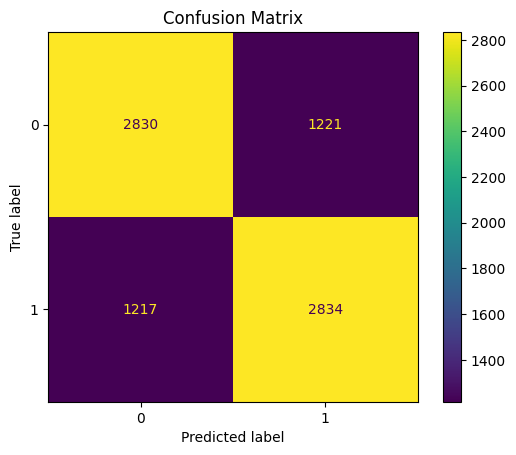

In [226]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_new_test, y_new_pred)
plt.title('Confusion Matrix')

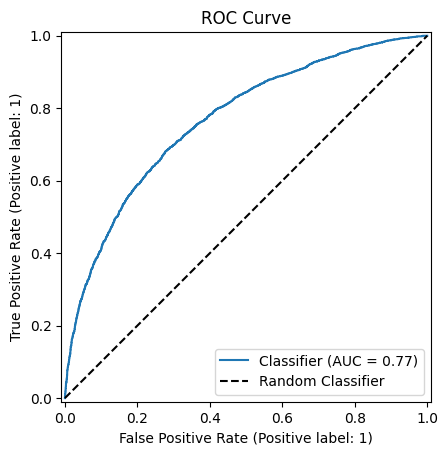

In [227]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_new_test, y_new_proba)
plt.title('ROC Curve')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

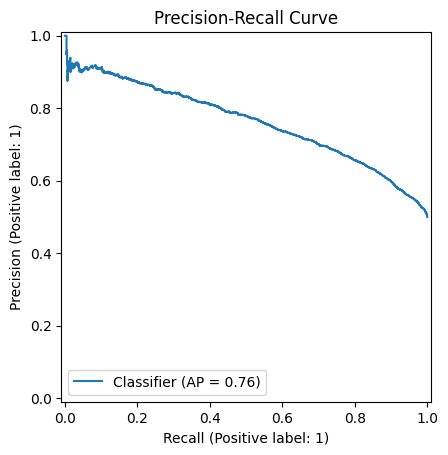

In [228]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision-Recall Curve')
plt.show()

In [229]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier

# =========================
# PREPARE TRAIN DATA
# =========================
X_new = df_new.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y_new = df_new['TARGET']

# One-hot encoding
X_new = pd.get_dummies(X_new)

# Clean column names (match Flask app)
X_new.columns = X_new.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

# =========================
# HANDLE IMBALANCE
# =========================
rus = RandomUnderSampler(random_state=42)
X_new_res, y_new_res = rus.fit_resample(X_new, y_new)

# =========================
# TRAIN MODEL
# =========================
model1 = LGBMClassifier()
model1.fit(X_new_res, y_new_res)

# =========================
# PROCESS TEST DATA
# =========================
df_test_new_processed = pd.get_dummies(df_test_new)

# Clean column names
df_test_new_processed.columns = df_test_new_processed.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

# Align with training columns (IMPORTANT)
df_test_new_processed = df_test_new_processed.reindex(columns=X_new.columns, fill_value=0)

# =========================
# PREDICT
# =========================


[LightGBM] [Info] Number of positive: 24670, number of negative: 24670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10268
[LightGBM] [Info] Number of data points in the train set: 49340, number of used features: 156
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [230]:
df_test_new['PRED'] = model1.predict_proba(df_test_new_processed)[:, 1]
# =========================
# PREDICT
# =========================

# =========================
# SAMPLE SEGMENT (MEDIUM RISK)
# =========================
medium = df_test_new[
    (df_test_new['PRED'] > 0.3) &
    (df_test_new['PRED'] <= 0.5)
]

medium.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,PAYMENT_COMPLETION_RATE,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,PRED
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,Unaccompanied,...,0.874970,0.0,1,0.035934,1,0,0,0,0,0.329590
11,100090,Cash loans,F,N,Y,0,135000.0,261621.0,16848.0,Unaccompanied,...,1.408567,0.0,1,0.000000,1,0,0,0,0,0.317758
14,100106,Revolving loans,M,N,Y,0,180000.0,157500.0,7875.0,"Spouse, partner",...,0.957212,0.0,1,0.000000,1,0,0,0,0,0.471431
17,100117,Cash loans,M,Y,Y,0,90000.0,499221.0,22117.5,Unaccompanied,...,0.999989,0.0,1,0.000000,0,0,1,0,0,0.345458
19,100141,Cash loans,F,Y,Y,0,175500.0,478498.5,46741.5,Family,...,0.999959,0.0,1,0.000000,1,0,1,0,0,0.358658


In [231]:
# predict (ONLY THIS)
df_test_new['PRED'] = model1.predict_proba(df_test_new_processed)[:,1]

# select low
low = df_test_new[
    (df_test_new['PRED'] <= 0.3)
].head(5)

low.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,PAYMENT_COMPLETION_RATE,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,PRED
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,Unaccompanied,...,0.999976,0.0,1,0.000000,1,0,0,0,0,0.208940
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,0,...,0.893771,0.0,1,0.137869,1,0,1,0,0,0.186386
6,100057,Cash loans,M,Y,Y,2,180000.0,499221.0,22117.5,Unaccompanied,...,0.999990,0.0,0,0.000000,1,0,1,0,0,0.188845
7,100065,Cash loans,M,N,Y,0,166500.0,180000.0,14220.0,Unaccompanied,...,0.999989,0.0,1,0.000000,1,0,0,0,0,0.278929
8,100066,Cash loans,F,N,Y,0,315000.0,364896.0,28957.5,Unaccompanied,...,0.999998,0.0,1,0.000000,1,0,0,0,0,0.117086


In [232]:
# predict (ONLY THIS)
df_test_new['PRED'] = model1.predict_proba(df_test_new_processed)[:,1]

# select medium
high = df_test_new[
    (df_test_new['PRED'] > 0.5)
].head(5)

high.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,...,PAYMENT_COMPLETION_RATE,SOCIAL_CIRCLE_DEFAULT_RATE,NO_SOCIAL_DATA,UTIL_BALANCE_RATIO,IS_EMPLOYED,RECENTLY_CHANGED_PHONE,HAS_CAR_AND_REALTY,IS_CHRONICALLY_LATE,HAS_ANY_DELAY,PRED
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,Unaccompanied,...,0.999982,0.0,1,0.000000,1,1,0,0,0,0.681576
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,Unaccompanied,...,0.999992,0.0,1,0.000000,1,0,0,0,0,0.625401
5,100042,Cash loans,F,Y,Y,0,270000.0,959688.0,34600.5,Unaccompanied,...,0.988093,0.0,1,0.423571,1,0,1,0,0,0.577012
9,100067,Cash loans,F,Y,Y,1,162000.0,45000.0,5337.0,Family,...,0.999998,0.0,0,0.604061,1,0,1,0,0,0.686873
12,100091,Cash loans,F,N,Y,0,247500.0,296280.0,23539.5,Unaccompanied,...,0.999976,0.0,0,0.000000,1,0,0,0,0,0.702822


In [233]:
print("LOW:\n", low[['SK_ID_CURR','PRED']])
print("MEDIUM:\n", medium[['SK_ID_CURR','PRED']])
print("HIGH:\n", high[['SK_ID_CURR','PRED']])

LOW:
    SK_ID_CURR      PRED
0      100001  0.208940
2      100013  0.186386
6      100057  0.188845
7      100065  0.278929
8      100066  0.117086
MEDIUM:
        SK_ID_CURR      PRED
3          100028  0.329590
11         100090  0.317758
14         100106  0.471431
17         100117  0.345458
19         100141  0.358658
...           ...       ...
48734      456168  0.325646
48738      456202  0.412340
48739      456221  0.307787
48740      456222  0.418794
48742      456224  0.362560

[14574 rows x 2 columns]
HIGH:
     SK_ID_CURR      PRED
1       100005  0.681576
4       100038  0.625401
5       100042  0.577012
9       100067  0.686873
12      100091  0.702822


In [234]:
print(len(X.columns))      # old
print(len(X_new.columns))  # new

186
162


In [235]:
import pickle
pickle.dump(model1, open('home_credit_default_model.pkl', 'wb'))

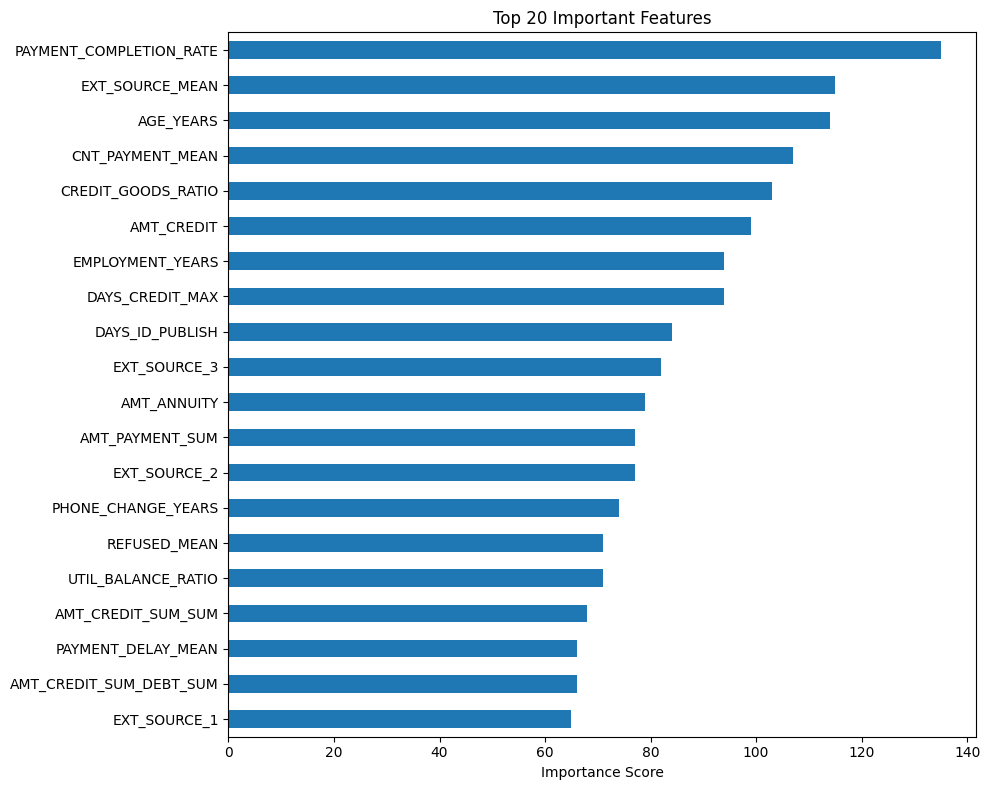

In [236]:
import matplotlib.pyplot as plt
import pandas as pd

# Create importance series
importance = pd.Series(model1.feature_importances_, index=X_new.columns)

# Get top 20 features
top_n = 20
importance_top = importance.nlargest(top_n).sort_values()

# Plot
plt.figure(figsize=(10, 8))
importance_top.plot(kind='barh')

plt.title(f'Top {top_n} Important Features')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.savefig('important_features_ranked.png')
plt.show()

In [214]:
print(df_test_new.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE',
       'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'I

In [86]:
df_train['TARGET'].value_counts()

TARGET
0    281051
1     24670
Name: count, dtype: int64